## Serial EnSRF

In [3]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

## Lorenz96モデルの定義
def L96(x, F):
    """
    x: shape (N,) または (N, M)
    F: スカラーまたは shape (N, 1/ M とブロードキャスト可能)
    """
    x = np.asarray(x)
    roll_p1 = np.roll(x, -1, axis=0)
    roll_m1 = np.roll(x, 1, axis=0)
    roll_m2 = np.roll(x, 2, axis=0)
    return (roll_p1 - roll_m2) * roll_m1 - x + F
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    return [np.random.normal(mean, std, j) for _ in range(N)]

def make_homogeneous_H(n, p):
    """
    p x n の均等観測演算子 H を作成する。
    観測は状態ベクトル長 n の要素から均等間隔で p 個を選ぶ（重複しないよう int に丸める）。
    戻り値:
      H : ndarray, shape (p, n)  -- 観測演算子（選んだ要素に対応する行が単位ベクトル）
      indices : ndarray, shape (p,) -- 観測に使う状態インデックス（0-based）
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    # 均等にインデックスを決める（端点を含める）
    indices = np.linspace(0, n - 1, p, dtype=int)
    # インデックスが重複する場合は調整（微小ずらし）
    # （通常は p<=n なら重複は起きにくいが念のため）
    uniq, counts = np.unique(indices, return_counts=True)
    if uniq.size != indices.size:
        # 重複を解消する簡易処理：採用済みインデックスを避けつつ前方に埋める
        used = set()
        new_idx = []
        for v in indices:
            if v in used:
                # 前後を探索して未使用インデックスを探す
                left = v - 1
                right = v + 1
                found = None
                while left >= 0 or right < n:
                    if left >= 0 and left not in used:
                        found = left
                        break
                    if right < n and right not in used:
                        found = right
                        break
                    left -= 1
                    right += 1
                if found is None:
                    raise RuntimeError("Cannot resolve duplicate observation indices")
                new_idx.append(found)
                used.add(found)
            else:
                new_idx.append(int(v))
                used.add(int(v))
        indices = np.array(new_idx, dtype=int)
    H = np.zeros((p, n), dtype=float)
    for i, idx in enumerate(indices):
        H[i, idx] = 1.0
    return H

def make_dense_H(n, p, dense=False, random_scale=0.01, seed=None):
    """
    n: 状態次元
    p: 観測次元
    dense: True にすると、(i,i)=1 に加えて残りの要素を小さい乱数で埋める（"dense" 化）
    random_scale: dense=True のときの乱数標準偏差
    seed: 乱数シード（再現性が欲しいときに指定）
    戻り値:
      H: ndarray, shape (p, n)
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    H = np.zeros((p, n), dtype=float)
    # 最初の p 行について対角成分 (i,i) を 1 にする
    for i in range(p):
        H[i, i] = 1.0

    if dense:
        rng = np.random.default_rng(seed)
        # 対角の位置は上書きしないようマスクを作る
        mask = np.ones((p, n), dtype=bool)
        for i in range(p):
            mask[i, i] = False
        H[mask] = rng.normal(loc=0.0, scale=random_scale, size=mask.sum())

    return H

Generating Nature Run (Lorenz96)...
Starting Assimilation...
Step 0/1460
Step 200/1460
Step 400/1460
Step 600/1460
Step 800/1460
Step 1000/1460
Step 1200/1460
Step 1400/1460
Plotting...


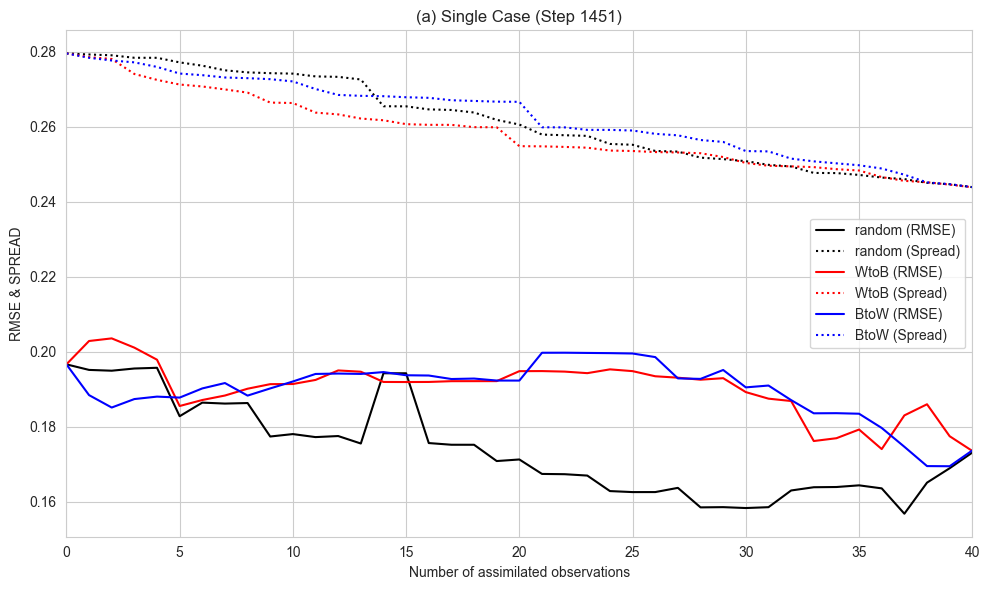

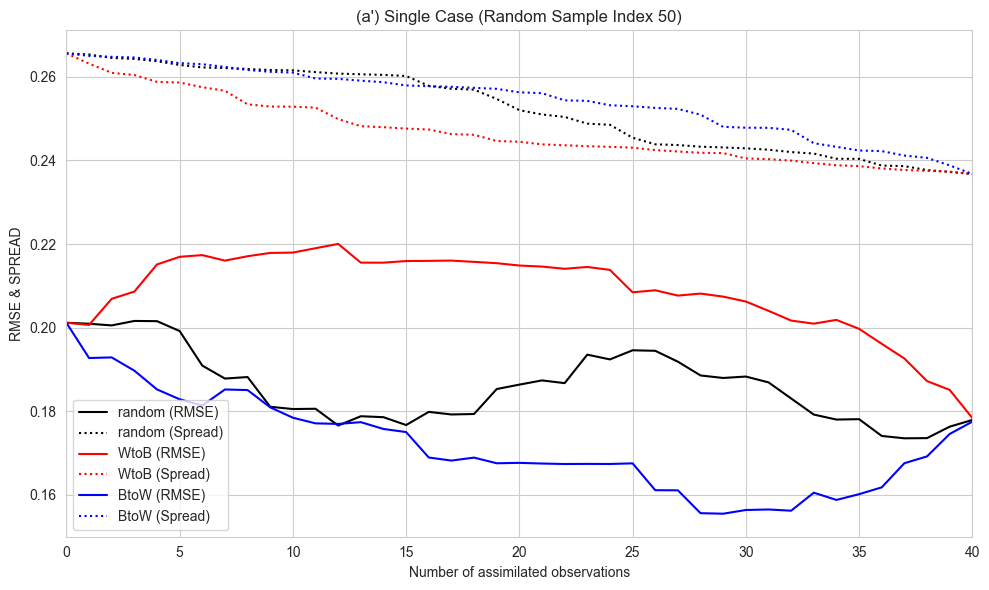

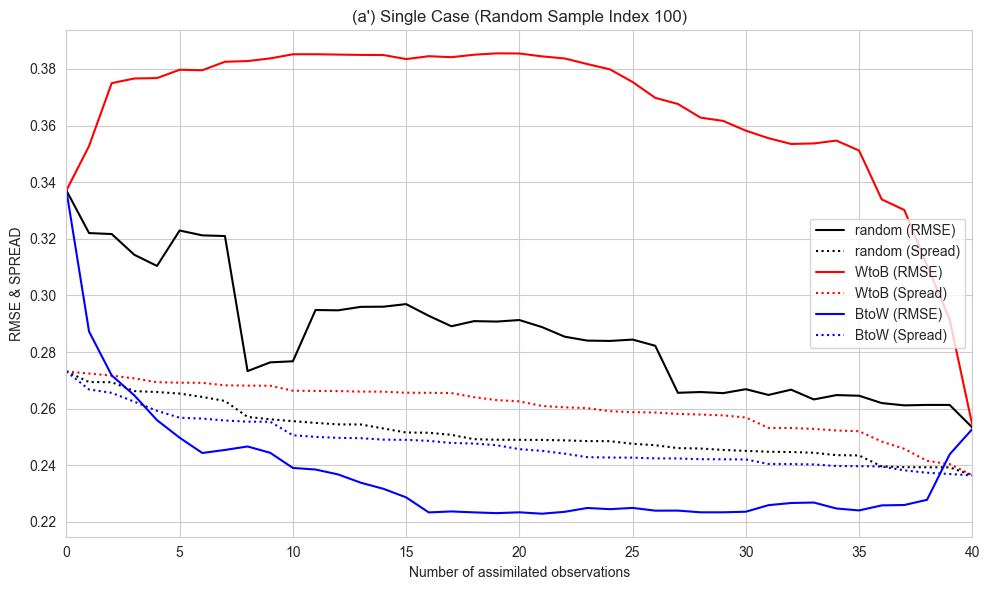

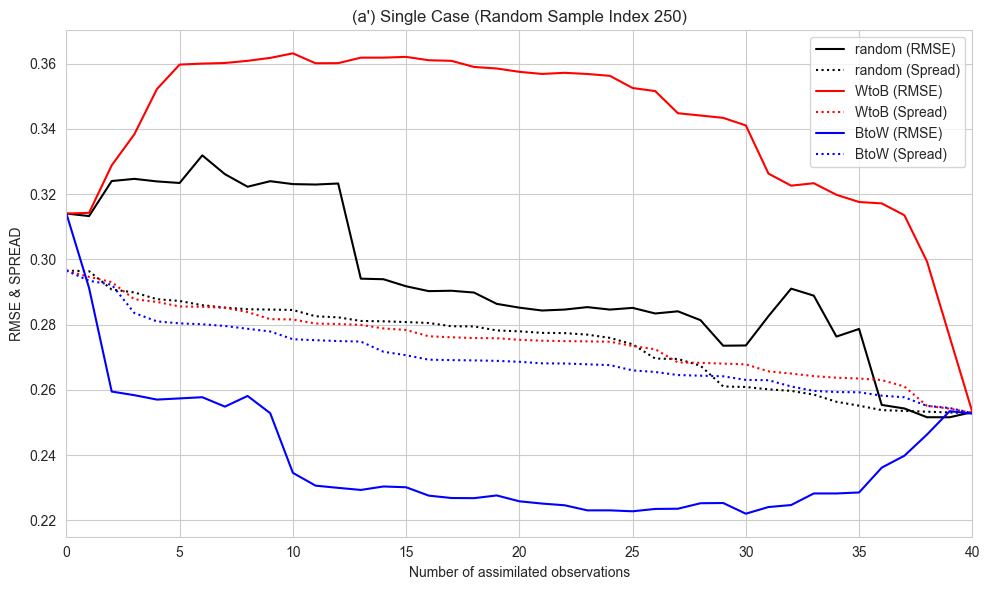

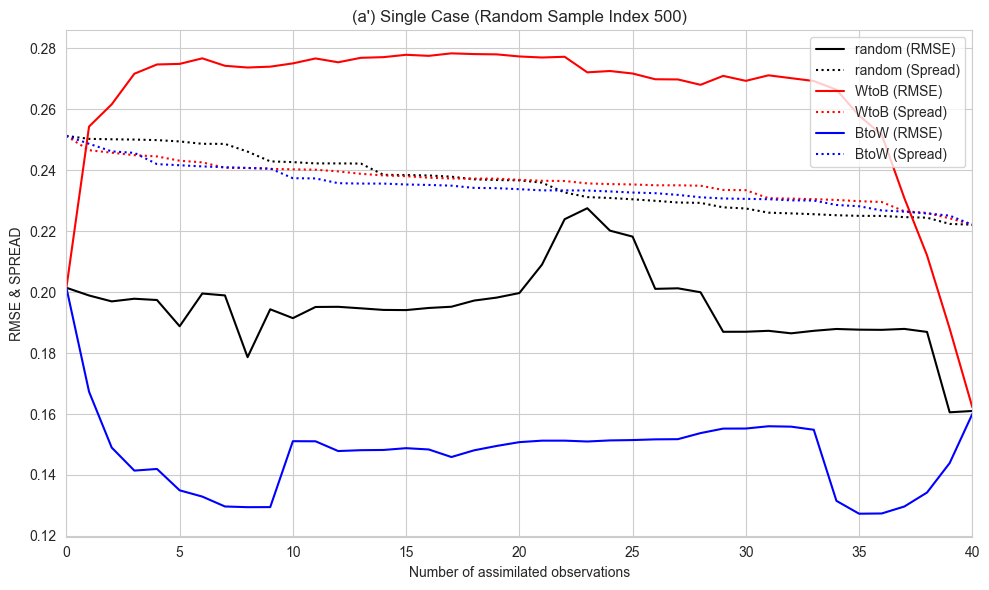

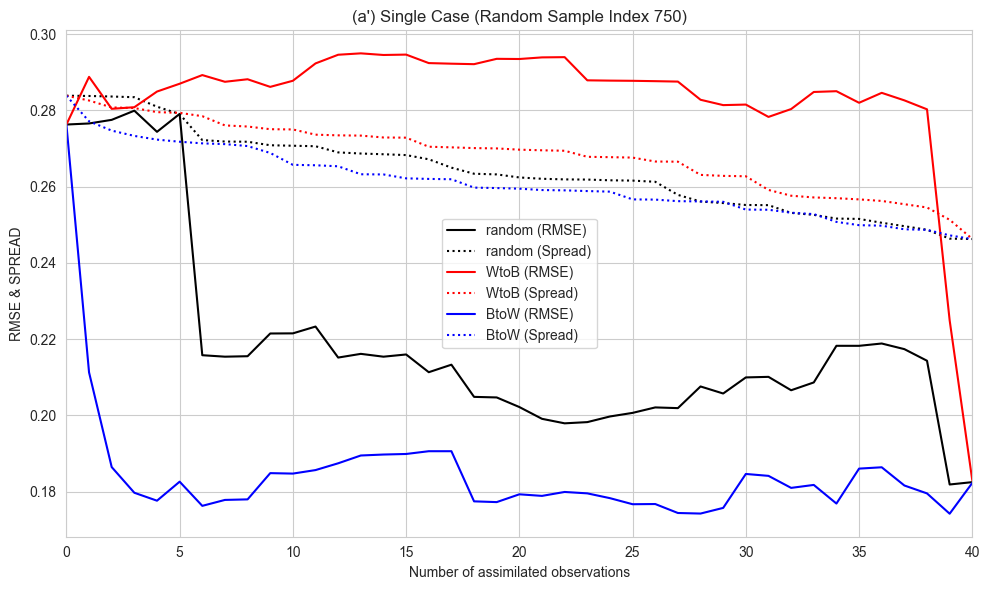

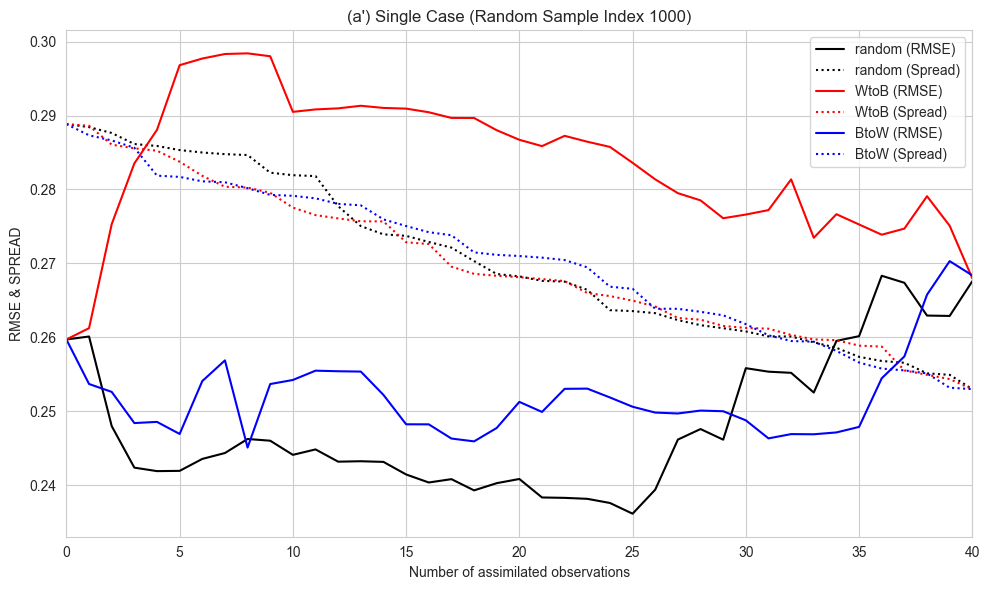

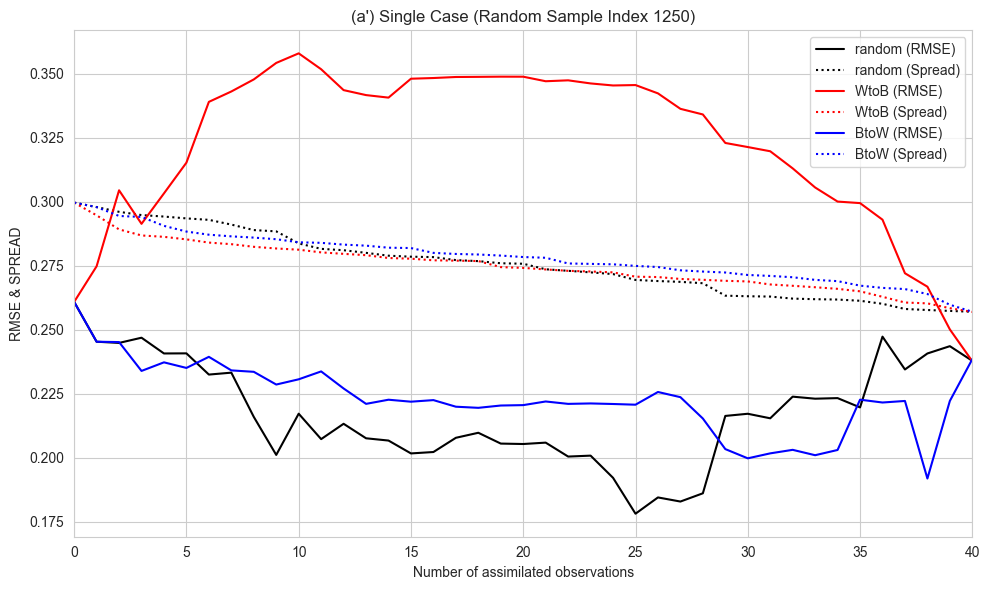

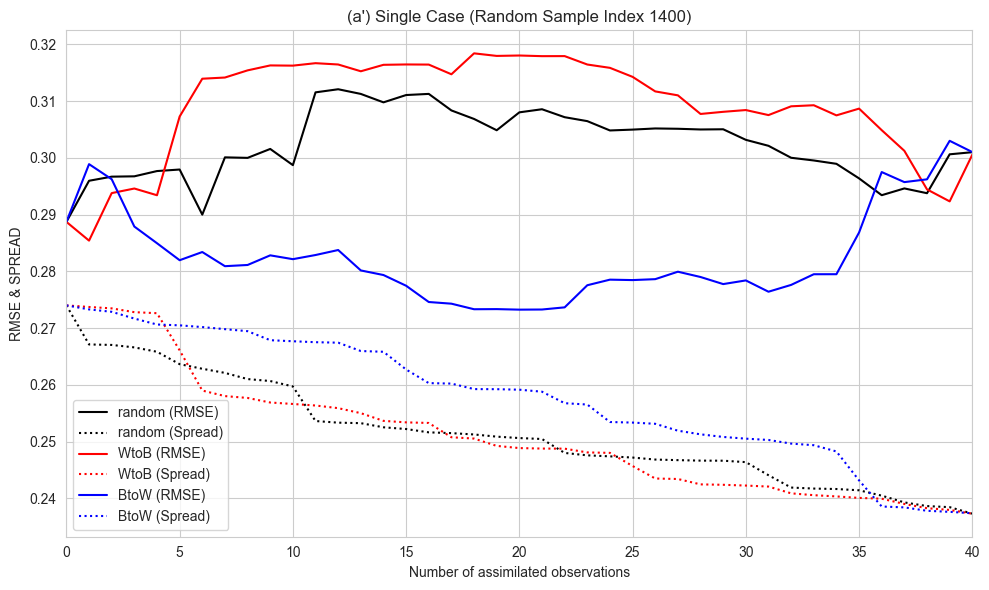

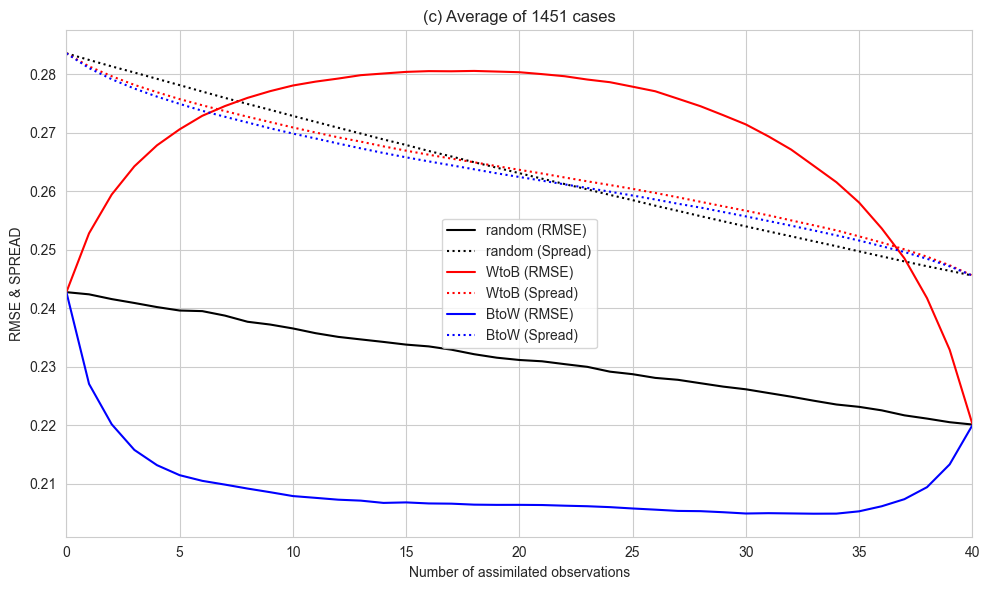

In [3]:
# ==========================================
# 1. EnKF_SerialEnSRF_EFSO Class (Modified)
# ==========================================
class EnKF_SerialEnSRF_EFSO:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=8, obs_error_std=1.0, inflation_factor=1.0, loc_radius=5):
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p) * (obs_error_std ** 2)
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.inflation_factor = inflation_factor
        self.ensemble = None
        self.Z = None
        self.Y = None
        
        # Gaspari-Cohn Localization Matrix
        self.L = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                dist = min(abs(i - j), N - abs(i - j))
                r = dist / (np.sqrt(10/3)*loc_radius)
                if r <= 1:
                    self.L[i, j] = 1 - (1/4)*r**5 + (1/2)*r**4 + (5/8)*r**3 - (5/3)*r**2
                elif r <= 2:
                    self.L[i, j] = (1/12)*r**5 - (1/2)*r**4 + (5/8)*r**3 + (5/3)*r**2 - 5*r + 4 - (2/3)*r**-1

    def initialize_ensemble(self, x0, initial_spread=1.0):
        np.random.seed(42)
        self.ensemble = x0[:, None] + np.random.normal(0, initial_spread, (self.N, self.ensemble_size))
        np.random.seed()

    def forecast(self):
        """予報ステップ: アンサンブルを時間発展させる"""
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = rk4_step(self.ensemble[:, i], self.F, self.dt)
        # ここでZを計算してもよいが、analysisの冒頭で再計算することで再同化時の整合性を保証する

    def analysis(self, observation, processing_order=None, monitor_truth=None):
        """
        解析ステップ (Serial EnSRF)
        """
        p = self.p
        y_obs = observation
        if processing_order is None: processing_order = np.arange(p)
        
        rmse_history, spread_history = [], []

        # 【重要修正】再同化のために、現在のアンサンブルから摂動行列Zを再構築する
        # これを行わないと、run_efso_cycleでensembleだけ戻してもZが解析後のままになり、Inflationが二重にかかる等のバグになる
        x_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - x_mean) / np.sqrt(self.ensemble_size - 1)

        # Inflation (Multiplicative)
        self.Z *= self.inflation_factor 
        self.Y = self.H @ self.Z  # 観測空間での摂動 Y = HZ
        
        # 記録用関数
        def record(curr_x, curr_Z):
            if monitor_truth is not None:
                err = curr_x.flatten() - monitor_truth
                rmse_history.append(np.sqrt(np.mean(err**2)))
                curr_ens = curr_x + curr_Z * np.sqrt(self.ensemble_size - 1)
                spread_history.append(np.sqrt(np.mean(np.var(curr_ens, axis=1, ddof=1))))
        
        record(x_mean, self.Z) # 初期状態(0個同化時点)

        # Serial Assimilation Loop
        for k in processing_order:
            row = self.H[k, :]
            obs_idx = np.flatnonzero(row)[0] # Hが対角行列等を仮定
            
            # Kalman Gain Calculation
            # P H^T = Z Y^T
            pf = self.Z @ self.Y[k, :].T
            # H P H^T + R = Y Y^T + R
            sk = (self.Y[k, :] @ self.Y[k, :].T) + self.R[k, k]
            
            # Localization
            K = (self.L[:, obs_idx][:, None] * pf[:, None]) / sk
            
            # State Update (Mean)
            innov = (y_obs[obs_idx] - (row @ x_mean)).reshape(1, 1)
            x_mean += K @ innov
            
            # Perturbation Update (EnSRF)
            shrink = 1.0 / (1.0 + np.sqrt(self.R[k, k] / sk))
            self.Z -= (K * shrink) @ self.Y[k, :][None, :]
            
            # Update Y for next observation
            self.Y = self.H @ self.Z
            
            record(x_mean, self.Z)

        # アンサンブル復元
        self.ensemble = x_mean + self.Z * np.sqrt(self.ensemble_size - 1)
        
        if monitor_truth is not None:
            return np.array(rmse_history), np.array(spread_history)

    def calculate_efso_impact(self, observation, x_bg_mean, future_reference, steps):
        """
        [cite_start]EFSOによる各観測のインパクト推定 [cite: 137, 167]
        Formula (Slide 167):
          J approx 1/(m-1) * dy^T * R^-1 * Y^a * X^f^T * C * (e_{t|0} + e_{t|-6})
        """
        m = self.ensemble_size
        p = self.p
        
        # 1. 解析摂動 X^a (Slide 150: dX_0^a)
        # self.ensembleは解析後の状態になっている前提
        xa_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Xa_pert = self.ensemble - xa_mean
        
        # 2. 予報摂動の発展 X^f (X_{t|0}^b)
        # 接線形モデルMの代わりに、非線形発展の差分で近似する
        ens_fcst = self.ensemble.copy()
        
        # 検証時刻 t まで積分
        for _ in range(steps):
            for i in range(m):
                ens_fcst[:,i] = rk4_step(ens_fcst[:,i], self.F, self.dt)
                
        xf_mean = np.mean(ens_fcst, axis=1, keepdims=True)
        Xf_pert = ens_fcst - xf_mean # -> X_{t|0}^b
        
        # 3. 誤差ベクトルの計算 (Slide 166: e_{t|0} + e_{t|-6})
        # バックグラウンド(x_bg_mean)も積分して e_{t|-6} を得る
        xf_analy_mean = xa_mean.copy()
        xf_bg_mean = x_bg_mean.reshape(-1, 1).copy()
        for _ in range(steps):
            xf_analy_mean[:,0] = rk4_step(xf_analy_mean[:,0], self.F, self.dt)
            xf_bg_mean[:,0] = rk4_step(xf_bg_mean[:,0], self.F, self.dt)
            
        e_t_0 = xf_analy_mean - future_reference.reshape(-1,1)     # 解析値からの予報誤差
        e_t_m1 = xf_bg_mean - future_reference.reshape(-1,1)       # バックグラウンドからの予報誤差
        total_error = e_t_0 + e_t_m1
        
        # 4. インパクトJの計算
        # Term: X^a * (X^f)^T * C * Error
        # Norm C = I (Identity) for L96 (Slide 114)
        
        # w = (X^f)^T * Error  [Shape: (m, 1)]
        weights = Xf_pert.T @ total_error
        
        # projection = X^a * w  [Shape: (N, 1)]
        projection = Xa_pert @ weights
        
        # Y^a space projection = H * projection [Shape: (p, 1)]
        # これが Slide 145 の Y_0^a * X_{t|0}^b^T * ... の部分に相当
        H_projection = self.H @ projection
        
        # Innovation delta_y (Slide 118: y^o - H x^b)
        y_bg = self.H @ x_bg_mean
        innovation = observation - y_bg
        
        impacts = np.zeros(p)
        factor = 1.0 / (m - 1)
        
        # 成分ごとに計算 (Rが対角行列であることを利用)
        for i in range(p):
            r_inv = 1.0 / self.R[i, i]
            # J_i = 1/(m-1) * innov_i * R_ii^-1 * (H_proj)_i
            impacts[i] = factor * innovation[i] * r_inv * H_projection[i, 0]
            
        return impacts

    def run_efso_cycle(self, observation, future_reference, verify_steps, current_truth):
        # バックグラウンド状態を保存
        bg_ens = self.ensemble.copy()
        x_bg_mean = np.mean(bg_ens, axis=1)
        
        # 0. default Order 準備
        default_order = np.arange(self.p)
        # 1. Random Order (Default)
        random_order = default_order.copy()
        np.random.shuffle(random_order)
        rmse_r, spread_r = self.analysis(observation, random_order, current_truth)
        
        # 2. EFSO Impact Calculation
        # 現在のself.ensembleは解析後(Random)の状態なので、これをX^aとして使用
        impacts = self.calculate_efso_impact(observation, x_bg_mean, future_reference, verify_steps)
        
        # 3. WtoB Order (Bad -> Good)
        # Impactが大きい(正=誤差増)順から同化することで、良い観測(負)を後に残す
        self.ensemble = bg_ens.copy() # リセット
        order_WtoB = np.argsort(impacts)[::-1]
        rmse_w, spread_w = self.analysis(observation, order_WtoB, current_truth)

        # 4. BtoW Order (Good -> Bad)
        self.ensemble = bg_ens.copy() # リセット
        order_BtoW = np.argsort(impacts)
        rmse_b, spread_b = self.analysis(observation, order_BtoW, current_truth)

        # 次のサイクルのために、デフォルト順（インデックス順）で解析して終了
        self.ensemble = bg_ens.copy()
        self.analysis(observation, default_order)
        
        return {
            'random': {'rmse': rmse_r, 'spread': spread_r},
            'WtoB':   {'rmse': rmse_w, 'spread': spread_w},
            'BtoW':   {'rmse': rmse_b, 'spread': spread_b}
        }

# ==========================================
# 2. Main Execution & Visualization
# ==========================================
print("Generating Nature Run (Lorenz96)...")
N = 40; F = 8.0; dt = 0.05; ensemble_size = 8; loc_radius = 5
days = 365
total_steps = 1460 # 1年分
pre_spinup = 1000

# 真値生成
true_states = np.zeros((pre_spinup + total_steps + 20, N))
x = np.random.randn(N) + F
for _ in range(pre_spinup): x = rk4_step(x, F, dt)
for t in range(total_steps + 20):
    x = rk4_step(x, F, dt)
    true_states[t, :] = x

# 観測生成
obs_error_std = 1.0
np.random.seed(42)
observed_states = true_states + np.random.normal(0, obs_error_std, true_states.shape)

# EnKF設定
print("Starting Assimilation...")
enkf = EnKF_SerialEnSRF_EFSO(N, F, dt, obs_error_std=obs_error_std, inflation_factor=1.05, ensemble_size=ensemble_size, loc_radius=loc_radius)
enkf.initialize_ensemble(true_states[0], initial_spread=1.0)

# 履歴保存用
histories = {'random':[], 'WtoB':[], 'BtoW':[]}
verify_steps = 8

for t in range(total_steps):
    if t >= total_steps - verify_steps - 1: break

    enkf.forecast()
    
    curr_obs = observed_states[t+1]
    curr_true = true_states[t+1]
    future_ref = true_states[t+1+verify_steps]
    
    res = enkf.run_efso_cycle(curr_obs, future_ref, verify_steps, curr_true)
    
    histories['random'].append(res['random'])
    histories['WtoB'].append(res['WtoB'])
    histories['BtoW'].append(res['BtoW'])
    
    if t % 200 == 0: print(f"Step {t}/{total_steps}")

# 描画
print("Plotting...")
sns.set_style("whitegrid")
x_axis = np.arange(N + 1)

# (a) Single Case (Last Step)
plt.figure(figsize=(10, 6))
last_idx = -1
for m, c in zip(['random', 'WtoB', 'BtoW'], ['k', 'r', 'b']):
    plt.plot(x_axis, histories[m][last_idx]['rmse'], c=c, label=f'{m} (RMSE)')
    plt.plot(x_axis, histories[m][last_idx]['spread'], c=c, ls=':', label=f'{m} (Spread)')
plt.title(f'(a) Single Case (Step {len(histories["random"])})')
plt.xlabel('Number of assimilated observations')
plt.ylabel('RMSE & SPREAD')
plt.xlim(0, 40)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# (a') Single Case (Random 5 sample)
# historiesの1451サンプルの中からランダムに5つ選ぶ
case_idx_list = np.random.choice(len(histories['random']), size=3, replace=False).sort()
case_idx_list = [50, 100, 250, 500, 750, 1000, 1250, 1400]
for case_idx in case_idx_list:
    plt.figure(figsize=(10, 6))
    for m, c in zip(['random', 'WtoB', 'BtoW'], ['k', 'r', 'b']):
        plt.plot(x_axis, histories[m][case_idx]['rmse'], c=c, label=f'{m} (RMSE)')
        plt.plot(x_axis, histories[m][case_idx]['spread'], c=c, ls=':', label=f'{m} (Spread)')
    plt.title(f"(a') Single Case (Random Sample Index {case_idx})")
    plt.xlabel('Number of assimilated observations')
    plt.ylabel('RMSE & SPREAD')
    plt.xlim(0, 40)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

# (c) Average
plt.figure(figsize=(10, 6))
for m, c in zip(['random', 'WtoB', 'BtoW'], ['k', 'r', 'b']):
    avg_rmse = np.mean([h['rmse'] for h in histories[m]], axis=0)
    avg_spread = np.mean([h['spread'] for h in histories[m]], axis=0)
    plt.plot(x_axis, avg_rmse, c=c, label=f'{m} (RMSE)')
    plt.plot(x_axis, avg_spread, c=c, ls=':', label=f'{m} (Spread)')
plt.title(f'(c) Average of {len(histories["random"])} cases')
plt.xlabel('Number of assimilated observations')
plt.ylabel('RMSE & SPREAD')
plt.xlim(0, 40)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

Generating Nature Run (Lorenz96)...
Starting Assimilation...
Step 0/1460
Step 200/1460
Step 400/1460
Step 600/1460
Step 800/1460
Step 1000/1460
Step 1200/1460
Step 1400/1460
Plotting...


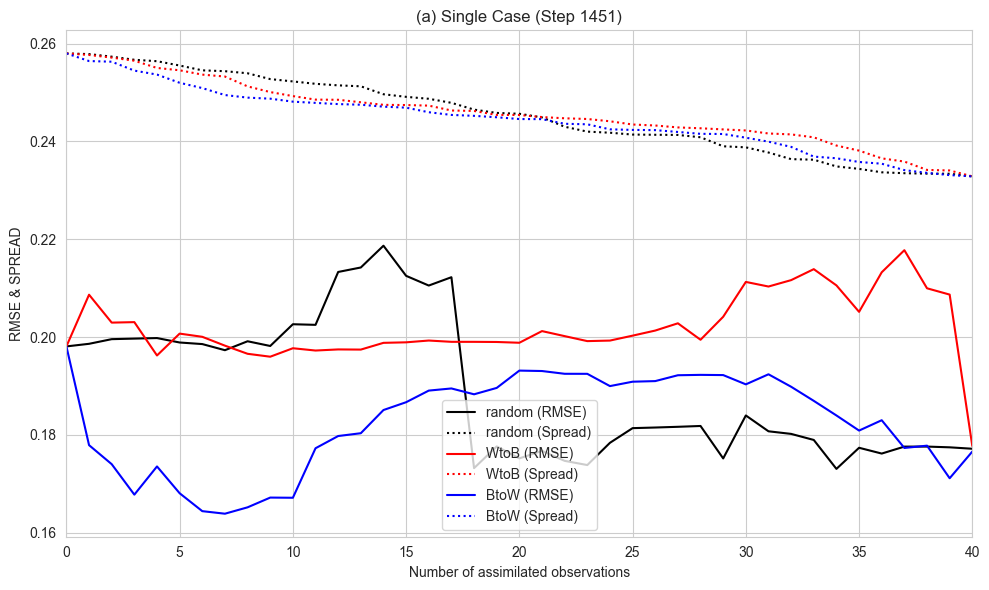

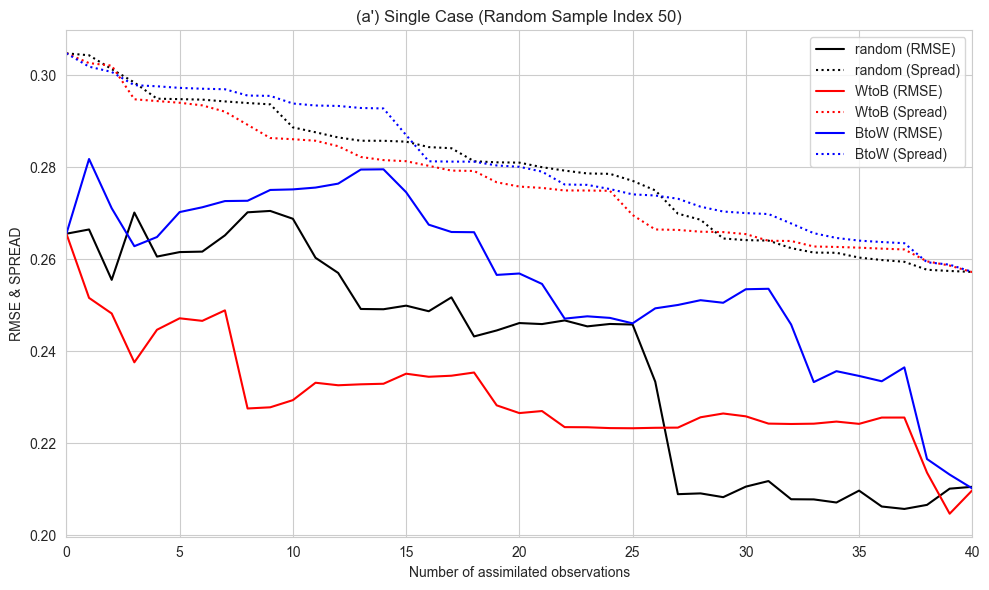

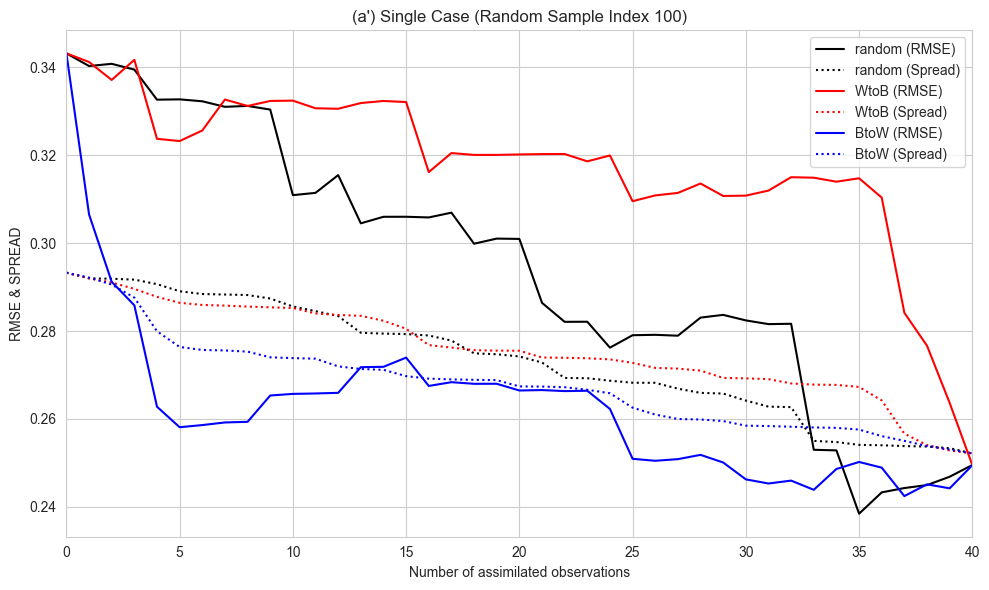

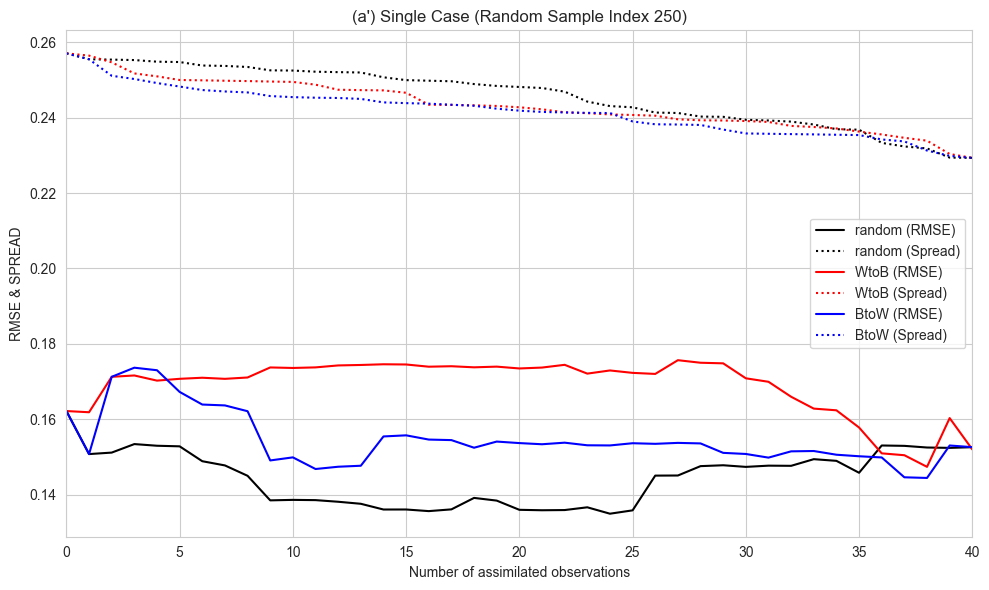

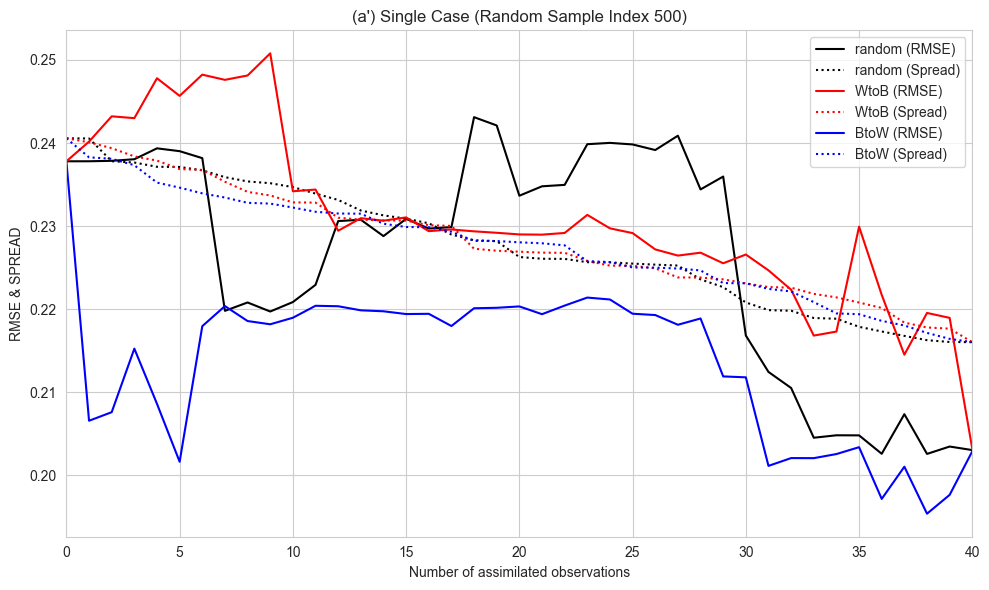

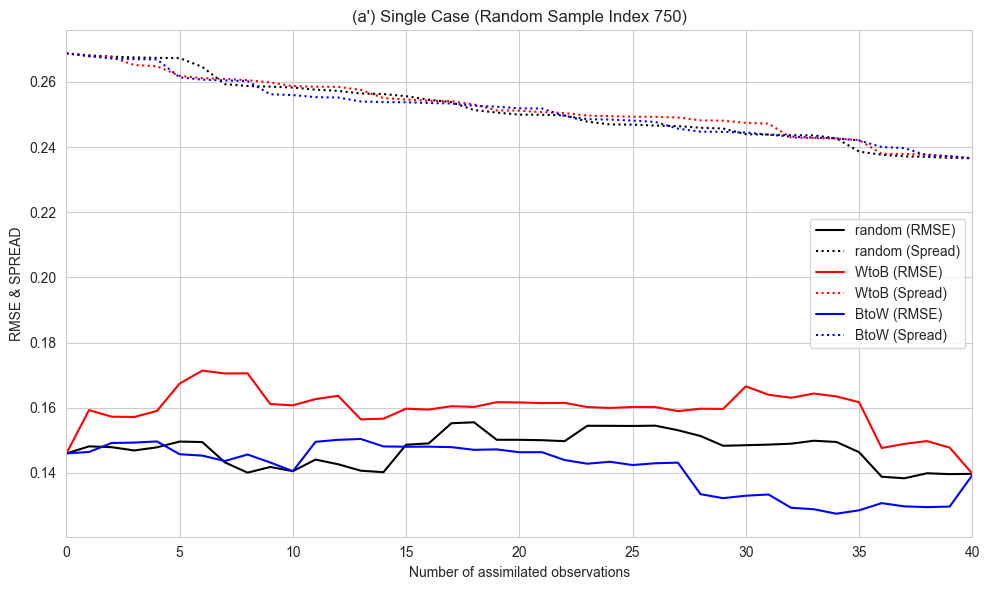

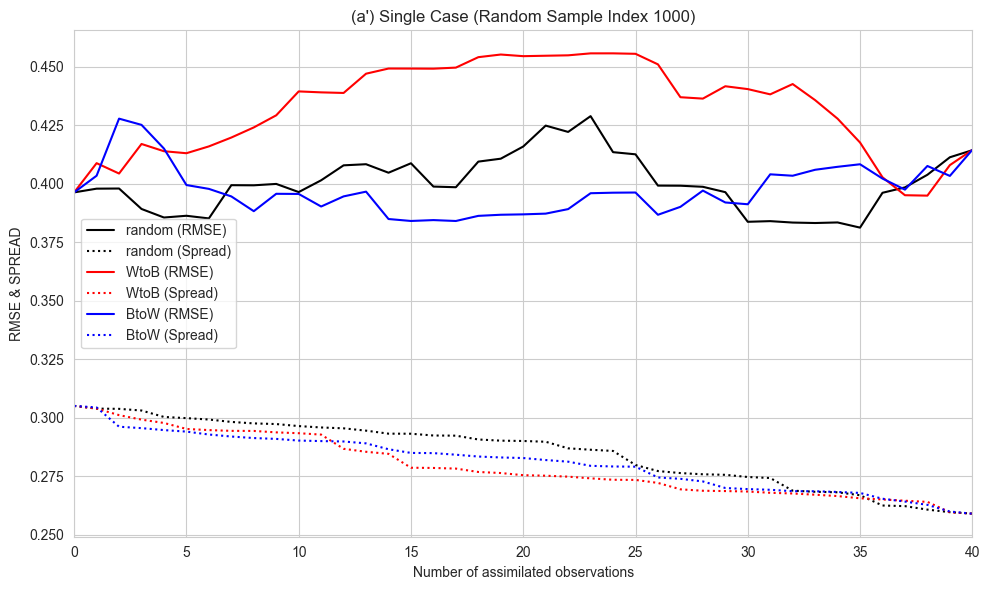

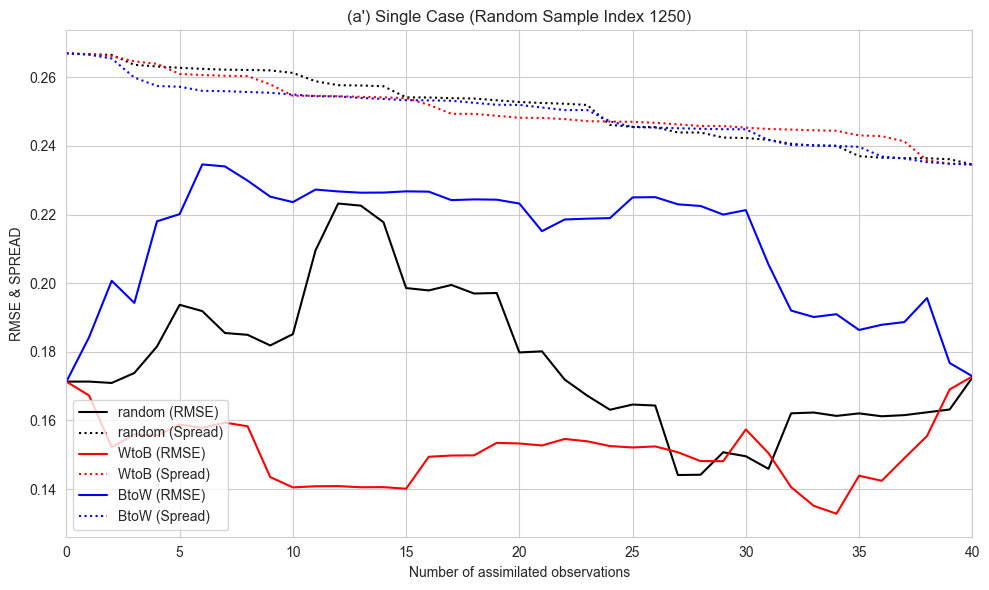

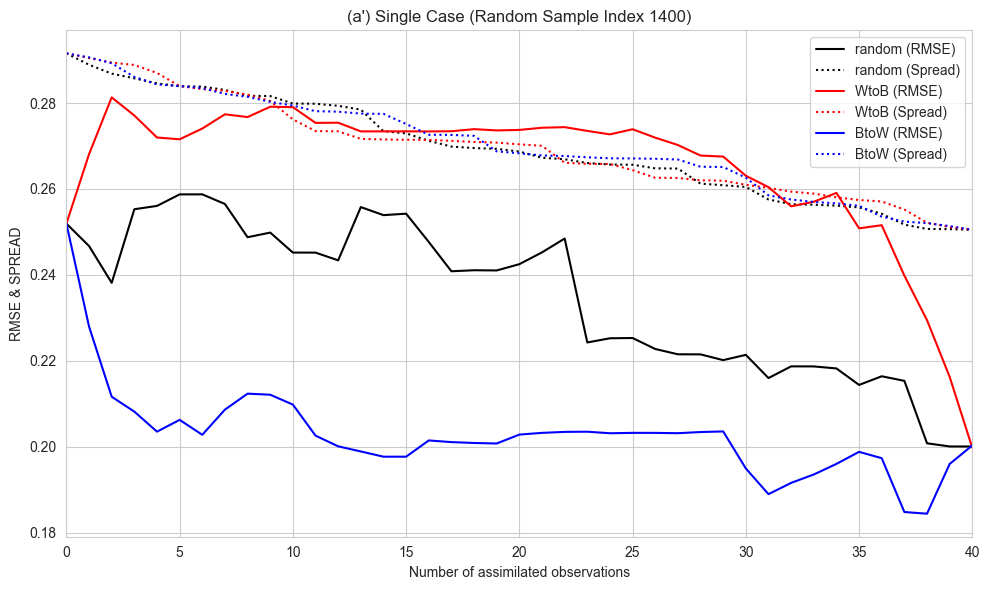

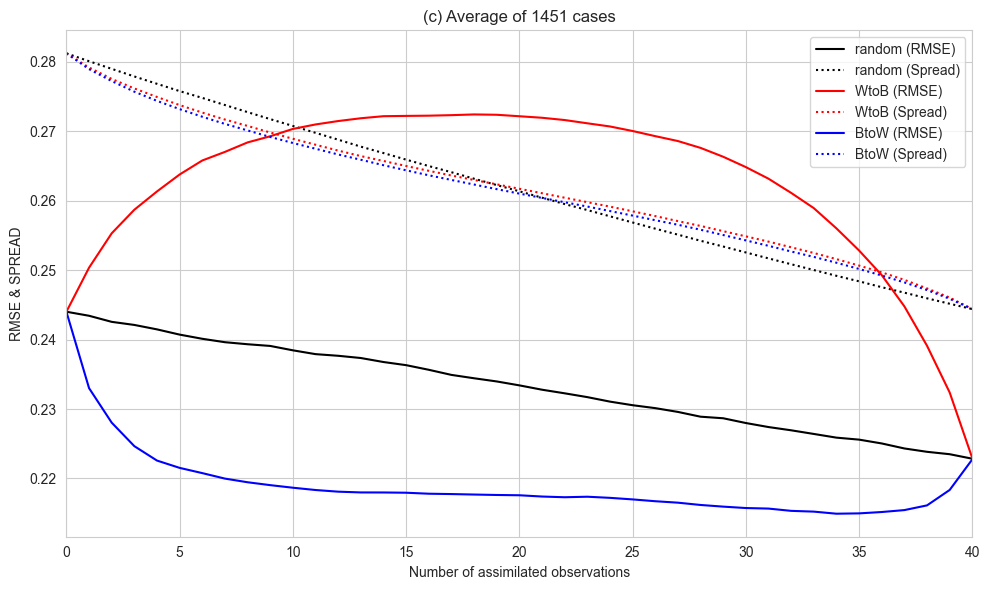

In [4]:
# ==========================================
# 1. EnKF_SerialEnSRF_EFSO Class (Modified)
# ==========================================
class EnKF_SerialEnSRF_EFSO:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=8, obs_error_std=1.0, inflation_factor=1.0, loc_radius=5):
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p) * (obs_error_std ** 2)
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.inflation_factor = inflation_factor
        self.ensemble = None
        self.Z = None
        self.Y = None
        
        # Gaspari-Cohn Localization Matrix
        self.L = np.zeros((N, N))
        for i in range(N):
            for j in range(N):
                dist = min(abs(i - j), N - abs(i - j))
                r = dist / (np.sqrt(10/3)*loc_radius)
                if r <= 1:
                    self.L[i, j] = 1 - (1/4)*r**5 + (1/2)*r**4 + (5/8)*r**3 - (5/3)*r**2
                elif r <= 2:
                    self.L[i, j] = (1/12)*r**5 - (1/2)*r**4 + (5/8)*r**3 + (5/3)*r**2 - 5*r + 4 - (2/3)*r**-1

    def initialize_ensemble(self, x0, initial_spread=1.0):
        np.random.seed(42)
        self.ensemble = x0[:, None] + np.random.normal(0, initial_spread, (self.N, self.ensemble_size))
        np.random.seed()

    def forecast(self):
        """予報ステップ: アンサンブルを時間発展させる"""
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = rk4_step(self.ensemble[:, i], self.F, self.dt)
        # ここでZを計算してもよいが、analysisの冒頭で再計算することで再同化時の整合性を保証する

    def analysis(self, observation, processing_order=None, monitor_truth=None):
        """
        解析ステップ (Serial EnSRF)
        """
        p = self.p
        y_obs = observation
        if processing_order is None: processing_order = np.arange(p)
        
        rmse_history, spread_history = [], []

        # 【重要修正】再同化のために、現在のアンサンブルから摂動行列Zを再構築する
        # これを行わないと、run_efso_cycleでensembleだけ戻してもZが解析後のままになり、Inflationが二重にかかる等のバグになる
        x_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - x_mean) / np.sqrt(self.ensemble_size - 1)

        # Inflation (Multiplicative)
        self.Z *= self.inflation_factor 
        self.Y = self.H @ self.Z  # 観測空間での摂動 Y = HZ
        
        # 記録用関数
        def record(curr_x, curr_Z):
            if monitor_truth is not None:
                err = curr_x.flatten() - monitor_truth
                rmse_history.append(np.sqrt(np.mean(err**2)))
                curr_ens = curr_x + curr_Z * np.sqrt(self.ensemble_size - 1)
                spread_history.append(np.sqrt(np.mean(np.var(curr_ens, axis=1, ddof=1))))
        
        record(x_mean, self.Z) # 初期状態(0個同化時点)

        # Serial Assimilation Loop
        for k in processing_order:
            row = self.H[k, :]
            obs_idx = np.flatnonzero(row)[0] # Hが対角行列等を仮定
            
            # Kalman Gain Calculation
            # P H^T = Z Y^T
            pf = self.Z @ self.Y[k, :].T
            # H P H^T + R = Y Y^T + R
            sk = (self.Y[k, :] @ self.Y[k, :].T) + self.R[k, k]
            
            # Localization
            K = (self.L[:, obs_idx][:, None] * pf[:, None]) / sk
            
            # State Update (Mean)
            innov = (y_obs[obs_idx] - (row @ x_mean)).reshape(1, 1)
            x_mean += K @ innov
            
            # Perturbation Update (EnSRF)
            shrink = 1.0 / (1.0 + np.sqrt(self.R[k, k] / sk))
            self.Z -= (K * shrink) @ self.Y[k, :][None, :]
            
            # Update Y for next observation
            self.Y = self.H @ self.Z
            
            record(x_mean, self.Z)

        # アンサンブル復元
        self.ensemble = x_mean + self.Z * np.sqrt(self.ensemble_size - 1)
        
        if monitor_truth is not None:
            return np.array(rmse_history), np.array(spread_history)

    def calculate_efso_impact(self, observation, x_bg_mean, future_reference, steps):
        """
        [cite_start]EFSOによる各観測のインパクト推定 [cite: 137, 167]
        Formula (Slide 167):
          J approx 1/(m-1) * dy^T * R^-1 * Y^a * X^f^T * C * (e_{t|0} + e_{t|-6})
        """
        m = self.ensemble_size
        p = self.p
        
        # 1. 解析摂動 X^a (Slide 150: dX_0^a)
        # self.ensembleは解析後の状態になっている前提
        xa_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Xa_pert = self.ensemble - xa_mean
        
        # 2. 予報摂動の発展 X^f (X_{t|0}^b)
        # 接線形モデルMの代わりに、非線形発展の差分で近似する
        ens_fcst = self.ensemble.copy()
        
        # 検証時刻 t まで積分
        for _ in range(steps):
            for i in range(m):
                ens_fcst[:,i] = rk4_step(ens_fcst[:,i], self.F, self.dt)
                
        xf_mean = np.mean(ens_fcst, axis=1, keepdims=True)
        Xf_pert = ens_fcst - xf_mean # -> X_{t|0}^b
        
        # 3. 誤差ベクトルの計算 (Slide 166: e_{t|0} + e_{t|-6})
        # バックグラウンド(x_bg_mean)も積分して e_{t|-6} を得る
        xf_analy_mean = xa_mean.copy()
        xf_bg_mean = x_bg_mean.reshape(-1, 1).copy()
        for _ in range(steps):
            xf_analy_mean[:,0] = rk4_step(xf_analy_mean[:,0], self.F, self.dt)
            xf_bg_mean[:,0] = rk4_step(xf_bg_mean[:,0], self.F, self.dt)
            
        e_t_0 = xf_analy_mean - future_reference.reshape(-1,1)     # 解析値からの予報誤差
        e_t_m1 = xf_bg_mean - future_reference.reshape(-1,1)       # バックグラウンドからの予報誤差
        total_error = e_t_0 + e_t_m1
        
        # 4. インパクトJの計算
        # Term: X^a * (X^f)^T * C * Error
        # Norm C = I (Identity) for L96 (Slide 114)
        
        # w = (X^f)^T * Error  [Shape: (m, 1)]
        weights = Xf_pert.T @ total_error
        
        # projection = X^a * w  [Shape: (N, 1)]
        projection = Xa_pert @ weights
        
        # Y^a space projection = H * projection [Shape: (p, 1)]
        # これが Slide 145 の Y_0^a * X_{t|0}^b^T * ... の部分に相当
        H_projection = self.H @ projection
        
        # Innovation delta_y (Slide 118: y^o - H x^b)
        y_bg = self.H @ x_bg_mean
        innovation = observation - y_bg
        
        impacts = np.zeros(p)
        factor = 1.0 / (m - 1)
        
        # 成分ごとに計算 (Rが対角行列であることを利用)
        for i in range(p):
            r_inv = 1.0 / self.R[i, i]
            # J_i = 1/(m-1) * innov_i * R_ii^-1 * (H_proj)_i
            impacts[i] = factor * innovation[i] * r_inv * H_projection[i, 0]
            
        return impacts

    def run_efso_cycle(self, observation, future_reference, verify_steps, current_truth):
        # バックグラウンド状態を保存
        bg_ens = self.ensemble.copy()
        x_bg_mean = np.mean(bg_ens, axis=1)
        
        # 0. default Order 準備
        default_order = np.arange(self.p)
        # 1. Random Order (Default)
        random_order = default_order.copy()
        np.random.shuffle(random_order)
        rmse_r, spread_r = self.analysis(observation, random_order, current_truth)
        
        # 2. EFSO Impact Calculation
        # 現在のself.ensembleは解析後(Random)の状態なので、これをX^aとして使用
        impacts = self.calculate_efso_impact(observation, x_bg_mean, future_reference, verify_steps)
        
        # 3. WtoB Order (Bad -> Good)
        # Impactが大きい(正=誤差増)順から同化することで、良い観測(負)を後に残す
        self.ensemble = bg_ens.copy() # リセット
        order_WtoB = np.argsort(impacts)[::-1]
        rmse_w, spread_w = self.analysis(observation, order_WtoB, current_truth)

        # 4. BtoW Order (Good -> Bad)
        self.ensemble = bg_ens.copy() # リセット
        order_BtoW = np.argsort(impacts)
        rmse_b, spread_b = self.analysis(observation, order_BtoW, current_truth)

        # 次のサイクルのために、デフォルト順（インデックス順）で解析して終了
        self.ensemble = bg_ens.copy()
        self.analysis(observation, default_order)
        
        return {
            'random': {'rmse': rmse_r, 'spread': spread_r},
            'WtoB':   {'rmse': rmse_w, 'spread': spread_w},
            'BtoW':   {'rmse': rmse_b, 'spread': spread_b}
        }

# ==========================================
# 2. Main Execution & Visualization
# ==========================================
print("Generating Nature Run (Lorenz96)...")
N = 40; F = 8.0; dt = 0.05; ensemble_size = 8; loc_radius = 5
days = 365
total_steps = 1460 # 1年分
pre_spinup = 1000

# 真値生成
true_states = np.zeros((pre_spinup + total_steps + 20, N))
x = np.random.randn(N) + F
for _ in range(pre_spinup): x = rk4_step(x, F, dt)
for t in range(total_steps + 20):
    x = rk4_step(x, F, dt)
    true_states[t, :] = x

# 観測生成
obs_error_std = 1.0
np.random.seed(42)
observed_states = true_states + np.random.normal(0, obs_error_std, true_states.shape)

# EnKF設定
print("Starting Assimilation...")
enkf = EnKF_SerialEnSRF_EFSO(N, F, dt, obs_error_std=obs_error_std, inflation_factor=1.05, ensemble_size=ensemble_size, loc_radius=loc_radius)
enkf.initialize_ensemble(true_states[0], initial_spread=1.0)

# 履歴保存用
histories = {'random':[], 'WtoB':[], 'BtoW':[]}
verify_steps = 8

for t in range(total_steps):
    if t >= total_steps - verify_steps - 1: break

    enkf.forecast()
    
    curr_obs = observed_states[t+1]
    curr_true = true_states[t+1]
    future_ref = observed_states[t+1+verify_steps]
    
    res = enkf.run_efso_cycle(curr_obs, future_ref, verify_steps, curr_true)
    
    histories['random'].append(res['random'])
    histories['WtoB'].append(res['WtoB'])
    histories['BtoW'].append(res['BtoW'])
    
    if t % 200 == 0: print(f"Step {t}/{total_steps}")

# 描画
print("Plotting...")
sns.set_style("whitegrid")
x_axis = np.arange(N + 1)

# (a) Single Case (Last Step)
plt.figure(figsize=(10, 6))
last_idx = -1
for m, c in zip(['random', 'WtoB', 'BtoW'], ['k', 'r', 'b']):
    plt.plot(x_axis, histories[m][last_idx]['rmse'], c=c, label=f'{m} (RMSE)')
    plt.plot(x_axis, histories[m][last_idx]['spread'], c=c, ls=':', label=f'{m} (Spread)')
plt.title(f'(a) Single Case (Step {len(histories["random"])})')
plt.xlabel('Number of assimilated observations')
plt.ylabel('RMSE & SPREAD')
plt.xlim(0, 40)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# (a') Single Case (Random 5 sample)
# historiesの1451サンプルの中からランダムに5つ選ぶ
case_idx_list = np.random.choice(len(histories['random']), size=3, replace=False).sort()
case_idx_list = [50, 100, 250, 500, 750, 1000, 1250, 1400]
for case_idx in case_idx_list:
    plt.figure(figsize=(10, 6))
    for m, c in zip(['random', 'WtoB', 'BtoW'], ['k', 'r', 'b']):
        plt.plot(x_axis, histories[m][case_idx]['rmse'], c=c, label=f'{m} (RMSE)')
        plt.plot(x_axis, histories[m][case_idx]['spread'], c=c, ls=':', label=f'{m} (Spread)')
    plt.title(f"(a') Single Case (Random Sample Index {case_idx})")
    plt.xlabel('Number of assimilated observations')
    plt.ylabel('RMSE & SPREAD')
    plt.xlim(0, 40)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

# (c) Average
plt.figure(figsize=(10, 6))
for m, c in zip(['random', 'WtoB', 'BtoW'], ['k', 'r', 'b']):
    avg_rmse = np.mean([h['rmse'] for h in histories[m]], axis=0)
    avg_spread = np.mean([h['spread'] for h in histories[m]], axis=0)
    plt.plot(x_axis, avg_rmse, c=c, label=f'{m} (RMSE)')
    plt.plot(x_axis, avg_spread, c=c, ls=':', label=f'{m} (Spread)')
plt.title(f'(c) Average of {len(histories["random"])} cases')
plt.xlabel('Number of assimilated observations')
plt.ylabel('RMSE & SPREAD')
plt.xlim(0, 40)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## LETKF

=== Experiment Start (N=40, Mem=8) ===
1. Running LETKF with ALL observations...
2. Calculating EFSO impacts...
   -> Beneficial Observations: 23 / 40
3. Re-running LETKF with BENEFICIAL observations only...


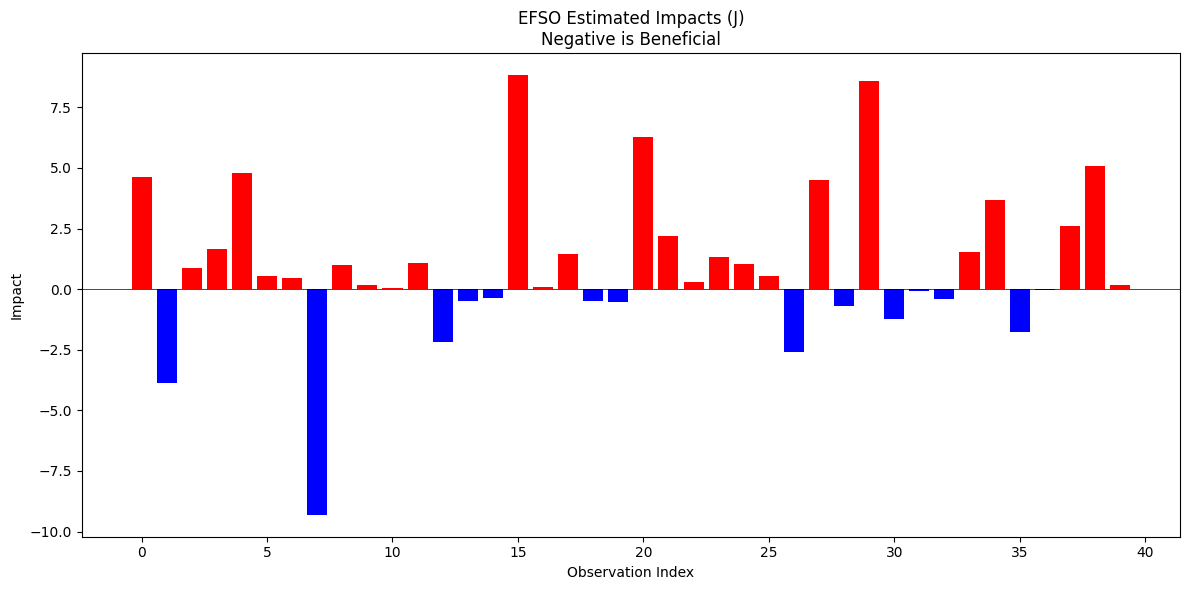

----------------------------------------
Analysis RMSE (At t=0)
  Control (All Obs) : 0.31048
  Proactive QC      : 0.18767
  Improvement       : 0.12281


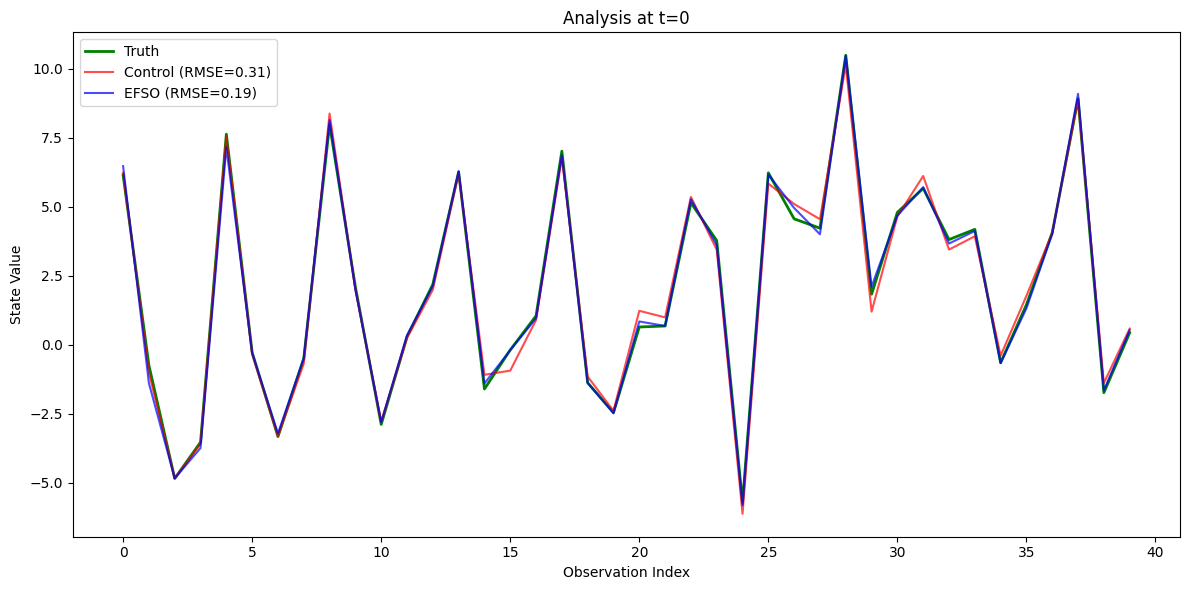

----------------------------------------
Forecast RMSE (Verify at t+0.40)
  Control (All Obs) : 1.20043
  Proactive QC      : 0.94492
  Improvement       : 0.25551
----------------------------------------


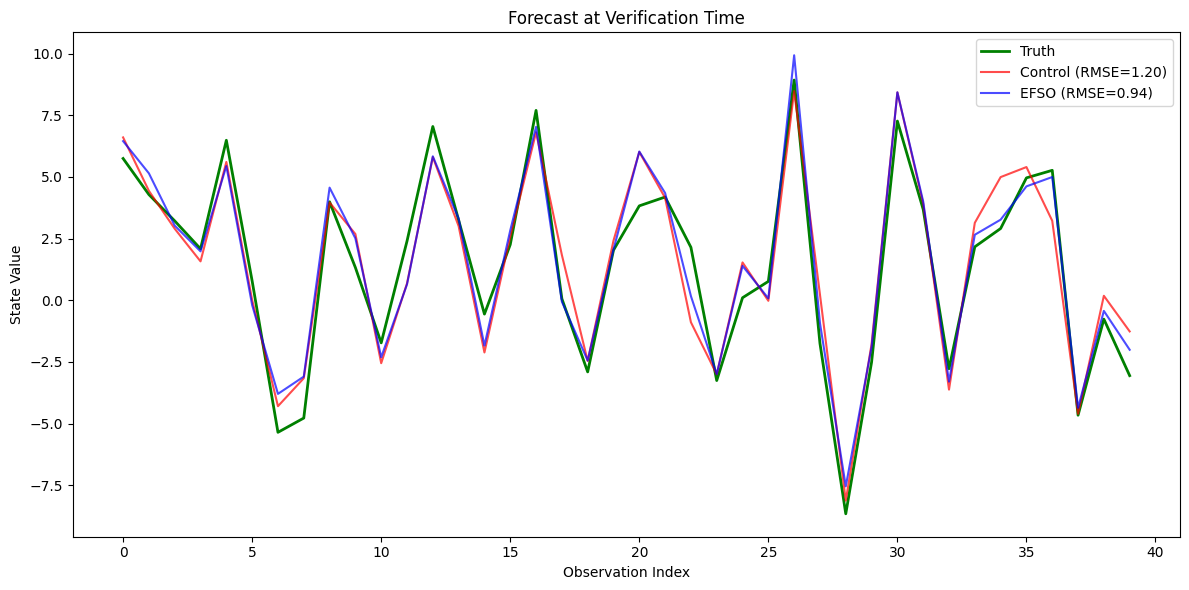

In [ ]:
# ==========================================
# 2. LETKF + EFSO クラスの実装
# ==========================================
class EnKF_LETKF_EFSO:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.05, loc_radius=5):
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p) * (obs_error_std**2)
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.inflation_factor = inflation_factor
        self.loc_radius = loc_radius
        
        # 観測インデックスの特定
        self.obs_indices = np.where(np.any(self.H, axis=0))[0]
        
        # 局所化行列の事前計算
        self.L_mat = self._create_localization_matrix()
        
        self.ensemble = None
        self.ensemble_mean = None

    def _create_localization_matrix(self):
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                if dist < 2 * np.sqrt(10/3) * self.loc_radius:
                    L[i, j] = np.exp(-0.5 * (dist / self.loc_radius) ** 2)
        return L

    def initialize_ensemble(self, x0, initial_spread=1.0):
        """初期アンサンブルの生成"""
        np.random.seed(42)
        # x0を中心に正規乱数でばらつかせる
        self.ensemble = x0[:, None] + np.random.normal(0, initial_spread, (self.N, self.ensemble_size))
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        np.random.seed()

    def forecast(self):
        """アンサンブル予報ステップ"""
        # ユーザー提供の rk4_step は (N, M) の形状に対応しているため、ループなしで一括計算可能
        self.ensemble = rk4_step(self.ensemble, self.F, self.dt)
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)

    def analysis(self, observation, active_obs_mask=None):
        """
        LETKF解析ステップ
        active_obs_mask: EFSO用。Trueの観測のみ同化に使用する。
        """
        # アンサンブル摂動行列 Z
        X_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z = (self.ensemble - X_mean) / np.sqrt(self.ensemble_size - 1)
        
        # Inflation
        Z *= self.inflation_factor
        
        # 観測空間への写像 Yb = HZ
        Yb = self.H @ Z
        
        # イノベーション d = y - Hx
        d = observation.reshape(-1, 1) - (self.H @ X_mean)
        
        # 解析アンサンブルの保存用
        Xa = np.zeros_like(self.ensemble)
        
        # Rの逆行列 (対角行列を仮定)
        R_inv_diag = 1.0 / np.diag(self.R)
        
        # グリッドポイントごとのループ (Local Analysis)
        for i in range(self.N):
            # 局所化ウェイト
            weights = self.L_mat[i, self.obs_indices]
            
            # --- [EFSO Proactive QC] ---
            # マスクがある場合、無効な観測のウェイトを0にする
            if active_obs_mask is not None:
                weights = weights * active_obs_mask
            
            # 有効な観測がない場合は更新しない
            if np.sum(weights) < 1e-10:
                Xa[i, :] = self.ensemble[i, :]
                continue
            
            # 局所化されたR^-1
            # R_loc_inv = R^-1 * weights
            R_loc_inv_diag = R_inv_diag * weights
            
            # P_tilde^-1 = (m-1)I + Yb^T R_loc^-1 Yb
            # ここでは定義に従い Z = X / sqrt(m-1) としているので
            # Cost Function J(w) = (m-1)/2 wTw + 1/2 (d - Yw)T R^-1 (d-Yw)
            # Hessian = (m-1)I + Y^T R^-1 Y
            # 固有値分解対象: I + Yb^T R_loc^-1 Yb (Z定義済みのため)
            
            # Yb^T @ R_loc_inv @ Yb の計算
            # Yb shape: (p, m), R_loc_inv_diag shape: (p,)
            Y_Rinv = Yb.T * R_loc_inv_diag[None, :] # Broadcasting
            Mat = np.eye(self.ensemble_size) + Y_Rinv @ Yb
            
            # 固有値分解
            try:
                evals, evecs = np.linalg.eigh(Mat)
            except np.linalg.LinAlgError:
                Xa[i, :] = self.ensemble[i, :]
                continue
                
            # 解析ウェイト行列 T の計算
            # T = P_tilde @ Yb^T @ R_loc^-1 @ d + sqrt(m-1) * P_tilde^1/2
            evals_inv = 1.0 / evals
            P_tilde = evecs @ np.diag(evals_inv) @ evecs.T
            P_tilde_sqrt = evecs @ np.diag(np.sqrt(evals_inv)) @ evecs.T
            
            # 平均更新用ウェイト w_bar
            w_bar = P_tilde @ Y_Rinv @ d
            
            # 摂動更新用ウェイト W_pert
            W_pert = np.sqrt(self.ensemble_size - 1) * P_tilde_sqrt
            
            # 解析アンサンブルへの更新
            # xa = x_mean + Z(w_bar + W_pert)
            # Z @ (w_bar + W_pert) を計算
            # w_bar: (m, 1), W_pert: (m, m) -> Total (m, m) (broadcast)
            W_total = w_bar + W_pert
            
            Xa[i, :] = X_mean[i, 0] + Z[i, :] @ W_total

        self.ensemble = Xa
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)

    def calculate_efso_impact(self, observation, bg_ensemble, future_reference, verify_steps):
        """
        EFSO感度計算
        bg_ensemble: 同化前の背景場アンサンブル
        future_reference: 検証用真値 (Verification Data)
        verify_steps: 検証時刻までのステップ数
        """
        m = self.ensemble_size
        
        # 1. 解析アンサンブル摂動 X^a
        # 現在のself.ensembleは「全観測同化後」の状態である必要がある
        xa_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Xa_pert = self.ensemble - xa_mean
        
        # 2. 予報アンサンブル摂動 X^f (背景場を発展)
        # 本来はTangent Linear Modelを使うが、非線形モデルの差分で近似
        xf_ens = bg_ensemble.copy()
        for _ in range(verify_steps):
            xf_ens = rk4_step(xf_ens, self.F, self.dt)
            
        xf_mean = np.mean(xf_ens, axis=1, keepdims=True)
        Xf_pert = xf_ens - xf_mean
        
        # 3. 予報誤差ベクトル e
        # e_{t|0}: 解析値からの予報誤差
        # e_{t|-1}: 背景場からの予報誤差
        
        # 解析値からの予報
        xa_fcst = self.ensemble.copy() # 全メンバ飛ばして平均を取る
        for _ in range(verify_steps):
            xa_fcst = rk4_step(xa_fcst, self.F, self.dt)
        xa_fcst_mean = np.mean(xa_fcst, axis=1, keepdims=True)
        
        # 背景場からの予報 (xf_meanと同じ)
        
        # 真値との差
        ref = future_reference.reshape(-1, 1)
        e_t_0 = xa_fcst_mean - ref
        e_t_m1 = xf_mean - ref
        
        total_error = e_t_0 + e_t_m1
        
        # 4. EFSO式: J ~ 1/(m-1) * d^T * R^-1 * H * X^a * (X^f)^T * C * total_error
        # Norm C = Identity
        
        # w = (X^f)^T * total_error  (shape: m, 1)
        w = Xf_pert.T @ total_error
        
        # proj = X^a * w (shape: N, 1)
        proj = Xa_pert @ w
        
        # obs_proj = H * proj (shape: p, 1)
        obs_proj = self.H @ proj
        
        # Innovation d = y - Hx_b
        bg_mean = np.mean(bg_ensemble, axis=1, keepdims=True)
        innov = observation.reshape(-1, 1) - (self.H @ bg_mean)
        
        # 成分ごとのインパクト J_i
        # Rは対角行列と仮定
        R_diag = np.diag(self.R).reshape(-1, 1)
        factor = 1.0 / (m - 1)
        
        # J = factor * innov * (1/R) * obs_proj
        impacts = factor * innov * (1.0 / R_diag) * obs_proj
        
        return impacts.flatten()

# ==========================================
# 3. 実行スクリプト
# ==========================================
if __name__ == "__main__":
    # パラメータ
    N = 40
    F = 8.0
    dt = 0.05
    ens_size = 8
    verify_steps = 8  # 8ステップ先 (0.4 time units) で検証
    
    # 1. Nature Run (StateArrayを使用)
    nature = StateArray(N, F, dt, method='rk4')
    # Spinup
    for _ in range(1000):
        nature.step()
    
    # LETKF初期化
    letkf = EnKF_LETKF_EFSO(N, F, dt, ensemble_size=ens_size)
    letkf.initialize_ensemble(nature.x, initial_spread=0.5)
    
    print(f"=== Experiment Start (N={N}, Mem={ens_size}) ===")
    
    # --- 1サイクルの実験 ---
    
    # 1. 真値を進める (t -> t+1)
    prev_true = nature.x.copy()
    nature.step()
    current_true = nature.x.copy()
    
    # 2. 観測生成
    obs_std = 1.0
    obs = current_true + np.random.normal(0, obs_std, N)
    
    # 3. 予報ステップ (t -> t+1)
    letkf.forecast()
    
    # [重要] 解析前の背景場アンサンブルを保存 (再同化用)
    bg_ensemble = letkf.ensemble.copy()
    bg_mean = letkf.ensemble_mean.flatten()
    
    # 4. 全観測同化 (Control)
    print("1. Running LETKF with ALL observations...")
    letkf.analysis(obs, active_obs_mask=None)
    xa_control = letkf.ensemble_mean.flatten()
    
    # 5. 検証用データの準備 (未来の真値)
    # 検証時刻 (verify_steps先) の真値を作成
    future_nature = StateArray(N, F, dt)
    future_nature.x = current_true.copy()
    for _ in range(verify_steps):
        future_nature.step()
    verify_ref = future_nature.x + np.random.normal(0, 1, N)  # 微小摂動
    
    # 6. EFSO感度計算
    print("2. Calculating EFSO impacts...")
    # 現在のletkf.ensembleは「全観測同化後」なのでそのまま使用
    impacts = letkf.calculate_efso_impact(obs, bg_ensemble, verify_ref, verify_steps)
    
    # 7. 有効な観測の特定 (J < 0)
    beneficial_mask = impacts < 1
    n_ben = np.sum(beneficial_mask)
    print(f"   -> Beneficial Observations: {n_ben} / {N}")
    
    # 8. 再同化 (EFSO選別観測のみ)
    print("3. Re-running LETKF with BENEFICIAL observations only...")
    # アンサンブルを同化前にリセット
    letkf.ensemble = bg_ensemble.copy()
    letkf.ensemble_mean = np.mean(bg_ensemble, axis=1, keepdims=True)
    
    # 選別したマスクを適用して解析
    letkf.analysis(obs, active_obs_mask=beneficial_mask)
    xa_efso = letkf.ensemble_mean.flatten()
    
    # --- 結果比較 ---
    def calc_rmse(x1, x2):
        return np.sqrt(np.mean((x1 - x2)**2))
    
    # --- インパクトプロット ---
    # プロット
    plt.figure(figsize=(12, 6))
    plt.bar(range(N), impacts, color=['blue' if x<0 else 'red' for x in impacts])
    plt.axhline(0, color='k', lw=0.5)
    plt.title("EFSO Estimated Impacts (J)\nNegative is Beneficial")
    plt.xlabel("Observation Index")
    plt.ylabel("Impact")
    plt.tight_layout()
    plt.show()
    
    # --- 結果比較 (解析時刻 t=0) ---
    # 同化直後の状態 (xa_control, xa_efso) と、その時点の真値 (current_true) を比較
    rmse_anl_control = calc_rmse(xa_control, current_true)
    rmse_anl_efso     = calc_rmse(xa_efso, current_true)

    print("-" * 40)
    print("Analysis RMSE (At t=0)")
    print(f"  Control (All Obs) : {rmse_anl_control:.5f}")
    print(f"  EFSO (Beneficial Only)      : {rmse_anl_efso:.5f}")
    print(f"  Improvement       : {rmse_anl_control - rmse_anl_efso:.5f}")
    
    #プロット
    plt.figure(figsize=(12, 6))
    plt.plot(current_true, color='g', ls='-', label='Truth', lw=2)
    plt.plot(xa_control, color='r', ls='-', label=f'Control (RMSE={rmse_anl_control:.2f})', alpha=0.7)
    plt.plot(xa_efso, color='b', ls='-', label=f'EFSO (RMSE={rmse_anl_efso:.2f})', alpha=0.7)
    plt.xlabel("Observation Index")
    plt.ylabel("State Value")
    plt.title("Analysis at t=0")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # --- 結果比較 (検証時刻 t=verify) ---
    fcst_control = xa_control.copy()
    fcst_efso = xa_efso.copy()
    for _ in range(verify_steps):
        fcst_control = rk4_step(fcst_control, F, dt)
        fcst_efso = rk4_step(fcst_efso, F, dt)
        
    rmse_control = calc_rmse(fcst_control, verify_ref)
    rmse_efso = calc_rmse(fcst_efso, verify_ref)
    
    print("-" * 40)
    print(f"Forecast RMSE (Verify at t+{verify_steps*dt:.2f})")
    print(f"  Control (All Obs) : {rmse_control:.5f}")
    print(f"  EFSO (Beneficial Only)      : {rmse_efso:.5f}")
    print(f"  Improvement       : {rmse_control - rmse_efso:.5f}")
    print("-" * 40)
    
    plt.figure(figsize=(12, 6))
    plt.plot(verify_ref, color='g', ls='-', label='Truth', lw=2)
    plt.plot(fcst_control, color='r', ls='-', label=f'Control (RMSE={rmse_control:.2f})', alpha=0.7)
    plt.plot(fcst_efso, color='b', ls='-', label=f'EFSO (RMSE={rmse_efso:.2f})', alpha=0.7)
    plt.title("Forecast at Verification Time")
    plt.xlabel("Observation Index")
    plt.ylabel("State Value")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

Starting Data Assimilation Cycle for 1460 steps...


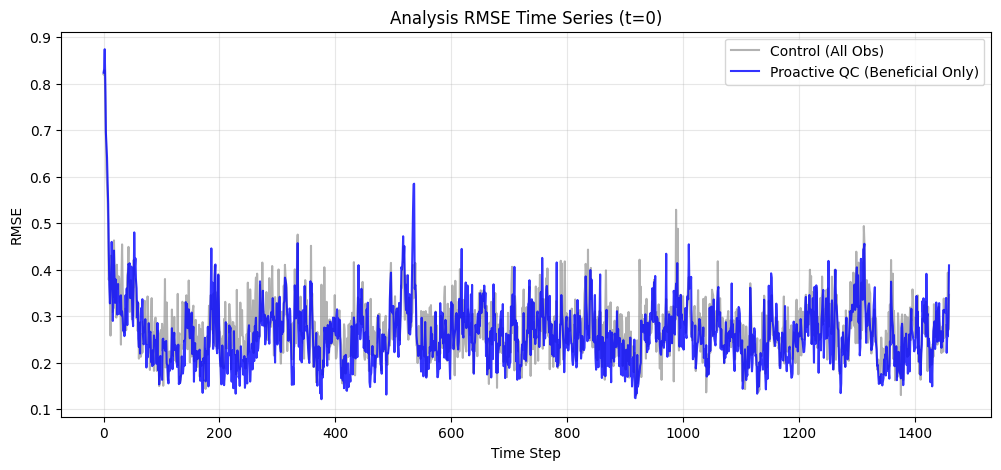

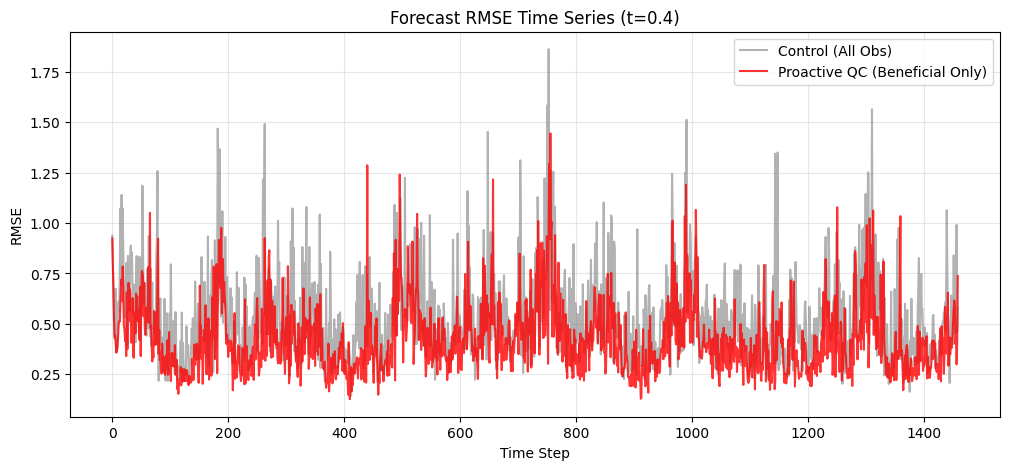

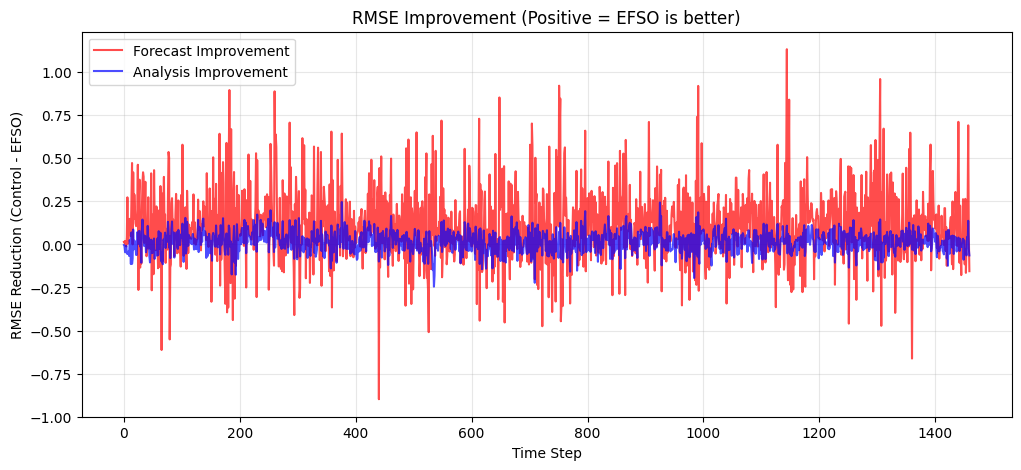

=== Summary (Averaged over 1460 steps) ===
Analysis RMSE: Control=0.2761, EFSO=0.2614
Forecast RMSE: Control=0.5307, EFSO=0.4180


In [ ]:
# ==========================================
# 2. LETKF + EFSO Class
# ==========================================
class EnKF_LETKF_EFSO:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.05, loc_radius=5):
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p) * (obs_error_std**2)
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.inflation_factor = inflation_factor
        self.loc_radius = loc_radius
        
        self.obs_indices = np.where(np.any(self.H, axis=0))[0]
        self.L_mat = self._create_localization_matrix()
        
        self.ensemble = None
        self.ensemble_mean = None

    def _create_localization_matrix(self):
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                if dist < 2 * np.sqrt(10/3) * self.loc_radius:
                    L[i, j] = np.exp(-0.5 * (dist / self.loc_radius) ** 2)
        return L

    def initialize_ensemble(self, x0, initial_spread=1.0):
        np.random.seed(42)
        self.ensemble = x0[:, None] + np.random.normal(0, initial_spread, (self.N, self.ensemble_size))
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        np.random.seed()

    def forecast(self):
        self.ensemble = rk4_step(self.ensemble, self.F, self.dt)
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)

    def analysis(self, observation, active_obs_mask=None):
        X_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z = (self.ensemble - X_mean) / np.sqrt(self.ensemble_size - 1)
        Z *= self.inflation_factor
        Yb = self.H @ Z
        d = observation.reshape(-1, 1) - (self.H @ X_mean)
        Xa = np.zeros_like(self.ensemble)
        R_inv_diag = 1.0 / np.diag(self.R)
        
        for i in range(self.N):
            weights = self.L_mat[i, self.obs_indices]
            if active_obs_mask is not None:
                # Apply mask to localization weights (effectively removing obs)
                weights = weights * active_obs_mask
            
            if np.sum(weights) < 1e-10:
                Xa[i, :] = self.ensemble[i, :]
                continue
            
            R_loc_inv_diag = R_inv_diag * weights
            Y_Rinv = Yb.T * R_loc_inv_diag[None, :] 
            Mat = np.eye(self.ensemble_size) + Y_Rinv @ Yb
            
            try:
                evals, evecs = np.linalg.eigh(Mat)
            except np.linalg.LinAlgError:
                Xa[i, :] = self.ensemble[i, :]
                continue
            
            evals_inv = 1.0 / evals
            P_tilde = evecs @ np.diag(evals_inv) @ evecs.T
            P_tilde_sqrt = evecs @ np.diag(np.sqrt(evals_inv)) @ evecs.T
            
            w_bar = P_tilde @ Y_Rinv @ d
            W_pert = np.sqrt(self.ensemble_size - 1) * P_tilde_sqrt
            W_total = w_bar + W_pert
            Xa[i, :] = X_mean[i, 0] + Z[i, :] @ W_total

        self.ensemble = Xa
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)

    def calculate_efso_impact(self, observation, bg_ensemble, future_reference, verify_steps):
        m = self.ensemble_size
        
        # 1. Analysis Perturbations (X^a)
        xa_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Xa_pert = self.ensemble - xa_mean
        
        # 2. Forecast Perturbations (X^f) from Background
        xf_ens = bg_ensemble.copy()
        for _ in range(verify_steps):
            xf_ens = rk4_step(xf_ens, self.F, self.dt)
        xf_mean = np.mean(xf_ens, axis=1, keepdims=True)
        Xf_pert = xf_ens - xf_mean
        
        # 3. Forecast Error Vector Calculation
        # E_{t|0}: Error of forecast initialized from Analysis (Current Best Est)
        xa_fcst = self.ensemble.copy()
        for _ in range(verify_steps):
            xa_fcst = rk4_step(xa_fcst, self.F, self.dt)
        xa_fcst_mean = np.mean(xa_fcst, axis=1, keepdims=True)
        
        # E_{t|-1}: Error of forecast initialized from Background
        # xf_mean is the forecast mean from background
        
        ref = future_reference.reshape(-1, 1)
        e_t_0 = xa_fcst_mean - ref
        e_t_m1 = xf_mean - ref
        total_error = e_t_0 + e_t_m1
        
        # 4. EFSO Impact Calculation
        # Formula: J ~ 1/(m-1) * d^T * R^-1 * H * X^a * (X^f)^T * Error
        w = Xf_pert.T @ total_error
        proj = Xa_pert @ w
        obs_proj = self.H @ proj
        
        bg_mean = np.mean(bg_ensemble, axis=1, keepdims=True)
        innov = observation.reshape(-1, 1) - (self.H @ bg_mean)
        
        R_diag = np.diag(self.R).reshape(-1, 1)
        factor = 1.0 / (m - 1)
        impacts = factor * innov * (1.0 / R_diag) * obs_proj
        
        return impacts.flatten()

# ==========================================
# 3. Main Execution Block
# ==========================================
if __name__ == "__main__":
    # Experiment Parameters
    N = 40
    F = 8.0
    dt = 0.05
    ens_size = 20 # Using 20 for stability in long run
    cycles = 1460  # 1 year (approx 365 days, 1 step = 6 hours)
    verify_steps = 8 # Verification at 2 days later
    
    # 1. Pre-compute Nature Run (Truth)
    # Generate truth for the entire period + verification window
    total_steps = cycles + verify_steps + 100
    truth_gen = StateArray(N, F, dt)
    
    # Spinup Nature Run
    for _ in range(1000):
        truth_gen.step()
    
    truth_trajectory = []
    for _ in range(total_steps):
        truth_gen.step()
        truth_trajectory.append(truth_gen.x.copy())
    truth_trajectory = np.array(truth_trajectory)
    
    # 2. Initialize LETKF
    letkf = EnKF_LETKF_EFSO(N, F, dt, ensemble_size=ens_size)
    letkf.initialize_ensemble(truth_trajectory[0], initial_spread=0.2)
    
    # Storage for RMSE history
    hist_rmse_anl_ctrl = []
    hist_rmse_anl_efso = []
    hist_rmse_fcst_ctrl = []
    hist_rmse_fcst_efso = []
    
    print(f"Starting Data Assimilation Cycle for {cycles} steps...")
    
    # 3. Main Cycle Loop
    for t in range(cycles):
        current_truth = truth_trajectory[t]
        future_truth = truth_trajectory[t + verify_steps]
        
        # Create Observation
        obs_noise = np.random.normal(0, 1.0, N)
        observation = current_truth + obs_noise
        
        # Forecast Step
        letkf.forecast()
        
        # Save Background (Before Analysis) for EFSO and Re-analysis
        bg_ensemble = letkf.ensemble.copy()
        bg_mean = letkf.ensemble_mean.copy()
        
        # --- (A) Control Analysis (All Observations) ---
        letkf.analysis(observation, active_obs_mask=None)
        xa_ctrl = letkf.ensemble_mean.flatten().copy()
        
        # --- (B) EFSO Calculation ---
        # Calculate impacts using Future Truth (in OSSE we know this)
        impacts = letkf.calculate_efso_impact(observation, bg_ensemble, future_truth, verify_steps)
        
        # Identify Beneficial Observations (Impact < 0)
        beneficial_mask = impacts < 0.0
        
        # --- (C) EFSO Analysis (Beneficial Obs Only) ---
        # Reset ensemble to background state
        letkf.ensemble = bg_ensemble.copy()
        letkf.ensemble_mean = bg_mean.copy()
        # Analyze with only beneficial observations
        letkf.analysis(observation, active_obs_mask=beneficial_mask)
        xa_efso = letkf.ensemble_mean.flatten().copy()
        
        # --- (D) Evaluation (RMSE Calculation) ---
        
        # 1. Analysis RMSE (at t=0)
        rmse_a_c = np.sqrt(np.mean((xa_ctrl - current_truth)**2))
        rmse_a_p = np.sqrt(np.mean((xa_efso - current_truth)**2))
        
        hist_rmse_anl_ctrl.append(rmse_a_c)
        hist_rmse_anl_efso.append(rmse_a_p)
        
        # 2. Forecast RMSE (at t=verify_steps)
        # We need to forecast from the new analyses to the verification time
        xf_c = xa_ctrl.copy()
        for _ in range(verify_steps):
            xf_c = rk4_step(xf_c, F, dt)
        rmse_f_c = np.sqrt(np.mean((xf_c - future_truth)**2))
        
        xf_p = xa_efso.copy()
        for _ in range(verify_steps):
            xf_p = rk4_step(xf_p, F, dt)
        rmse_f_p = np.sqrt(np.mean((xf_p - future_truth)**2))
        
        hist_rmse_fcst_ctrl.append(rmse_f_c)
        hist_rmse_fcst_efso.append(rmse_f_p)
        
        # Note: In this loop, the system state for the next cycle continues from `xa_efso`.
        # This means the "EFSO" benefit accumulates over time.

    # 4. Visualization
    time_axis = np.arange(cycles)
    
    # Plot Analysis RMSE
    control_avg_rmse_anl = np.mean(hist_rmse_anl_ctrl)
    efso_avg_rmse_anl = np.mean(hist_rmse_anl_efso)
    plt.figure(figsize=(12, 5))
    plt.plot(time_axis, hist_rmse_anl_ctrl, label=f'Control (All Obs) Avg: {control_avg_rmse_anl:.3f}', alpha=0.6, color='gray')
    plt.plot(time_axis, hist_rmse_anl_efso, label=f'EFSO (Beneficial Only) Avg: {efso_avg_rmse_anl:.3f}', alpha=0.8, color='blue')
    plt.title("Analysis RMSE Time Series (t=0)")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot Forecast RMSE
    control_avg_rmse_fcst = np.mean(hist_rmse_fcst_ctrl)
    efso_avg_rmse_fcst = np.mean(hist_rmse_fcst_efso)
    plt.figure(figsize=(12, 5))
    plt.plot(time_axis, hist_rmse_fcst_ctrl, label=f'Control (All Obs) Avg: {control_avg_rmse_fcst:.3f}', alpha=0.6, color='gray')
    plt.plot(time_axis, hist_rmse_fcst_efso, label=f'EFSO (Beneficial Only) Avg: {efso_avg_rmse_fcst:.3f}', alpha=0.8, color='red')
    plt.title(f"Forecast RMSE Time Series (t={verify_steps*dt:.1f})")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot Improvement
    imp_anl = np.array(hist_rmse_anl_ctrl) - np.array(hist_rmse_anl_efso)
    imp_fcst = np.array(hist_rmse_fcst_ctrl) - np.array(hist_rmse_fcst_efso)
    plt.figure(figsize=(12, 5))
    plt.axhline(0, color='black', lw=1)
    plt.plot(time_axis, imp_fcst, label='Forecast Improvement', color='red', alpha=0.7)
    plt.plot(time_axis, imp_anl, label='Analysis Improvement', color='blue', alpha=0.7)
    plt.title("RMSE Improvement (Positive = EFSO is better)")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE Reduction (Control - EFSO)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print Summary Statistics
    print(f"=== Summary (Averaged over {cycles} steps) ===")
    print(f"Analysis RMSE: Control={control_avg_rmse_anl:.4f}, EFSO={efso_avg_rmse_anl:.4f}")
    print(f"Forecast RMSE: Control={control_avg_rmse_fcst:.4f}, EFSO={efso_avg_rmse_fcst:.4f}")

Starting Diagnostic Experiment for 1460 steps...


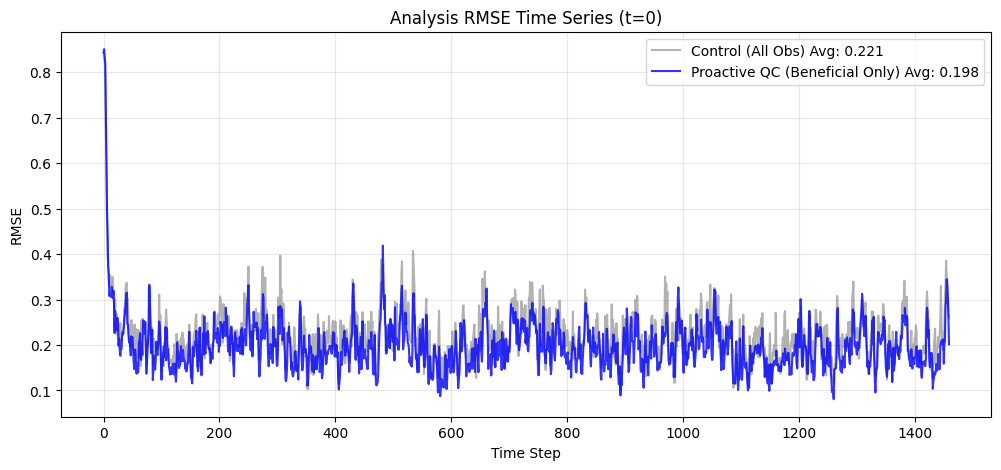

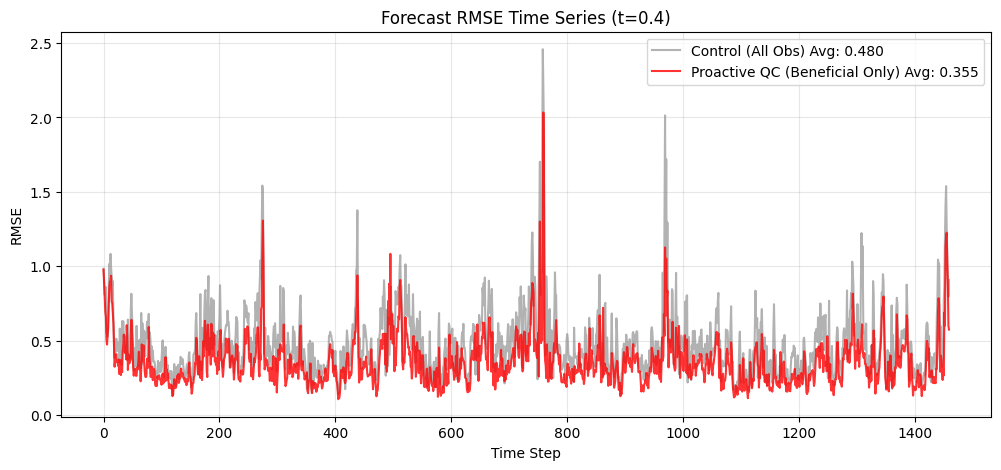

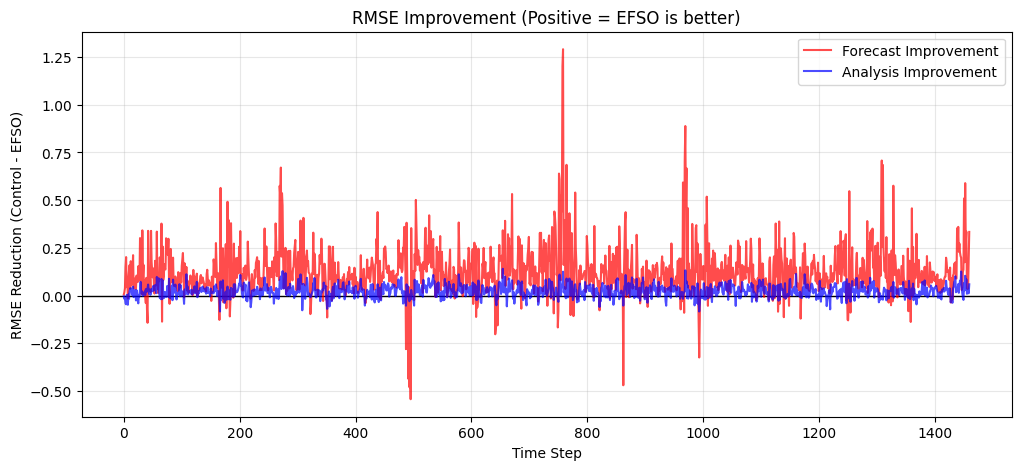

=== Summary (Averaged over 1460 steps) ===
Analysis RMSE: Control=0.2208, EFSO=0.1981
Forecast RMSE: Control=0.4803, EFSO=0.3546


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

# ==========================================
# 1. Lorenz96 Model & Utilities
# ==========================================
def L96(x, F):
    """Lorenz-96 model equation"""
    x = np.asarray(x)
    roll_p1 = np.roll(x, -1, axis=0)
    roll_m1 = np.roll(x, 1, axis=0)
    roll_m2 = np.roll(x, 2, axis=0)
    return (roll_p1 - roll_m2) * roll_m1 - x + F

def rk4_step(x, F, dt):
    """Runge-Kutta 4th order integration"""
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

class StateArray:
    def __init__(self, N, F, dt):
        self.N = N
        self.F = F
        self.dt = dt
        self.x = F * np.ones(N)
        self.x[N // 2 - 1] *= 1.001

    def step(self):
        self.x = rk4_step(self.x, self.F, self.dt)

# ==========================================
# 2. LETKF + EFSO Class
# ==========================================
class EnKF_LETKF_EFSO:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.05, loc_radius=5):
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p) * (obs_error_std**2)
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.inflation_factor = inflation_factor
        self.loc_radius = loc_radius
        
        self.obs_indices = np.where(np.any(self.H, axis=0))[0]
        self.L_mat = self._create_localization_matrix()
        
        self.ensemble = None
        self.ensemble_mean = None

    def _create_localization_matrix(self):
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                if dist < 2 * np.sqrt(10/3) * self.loc_radius:
                    L[i, j] = np.exp(-0.5 * (dist / self.loc_radius) ** 2)
        return L

    def initialize_ensemble(self, x0, initial_spread=1.0):
        np.random.seed(42)
        self.ensemble = x0[:, None] + np.random.normal(0, initial_spread, (self.N, self.ensemble_size))
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        np.random.seed()

    def forecast(self):
        self.ensemble = rk4_step(self.ensemble, self.F, self.dt)
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)

    def analysis(self, observation, active_obs_mask=None):
        X_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z = (self.ensemble - X_mean) / np.sqrt(self.ensemble_size - 1)
        Z *= self.inflation_factor
        Yb = self.H @ Z
        d = observation.reshape(-1, 1) - (self.H @ X_mean)
        Xa = np.zeros_like(self.ensemble)
        R_inv_diag = 1.0 / np.diag(self.R)
        
        for i in range(self.N):
            weights = self.L_mat[i, self.obs_indices]
            if active_obs_mask is not None:
                weights = weights * active_obs_mask
            
            if np.sum(weights) < 1e-10:
                Xa[i, :] = self.ensemble[i, :]
                continue
            
            R_loc_inv_diag = R_inv_diag * weights
            Y_Rinv = Yb.T * R_loc_inv_diag[None, :] 
            Mat = np.eye(self.ensemble_size) + Y_Rinv @ Yb
            
            try:
                evals, evecs = np.linalg.eigh(Mat)
            except np.linalg.LinAlgError:
                Xa[i, :] = self.ensemble[i, :]
                continue
            
            evals_inv = 1.0 / evals
            P_tilde = evecs @ np.diag(evals_inv) @ evecs.T
            P_tilde_sqrt = evecs @ np.diag(np.sqrt(evals_inv)) @ evecs.T
            
            w_bar = P_tilde @ Y_Rinv @ d
            W_pert = np.sqrt(self.ensemble_size - 1) * P_tilde_sqrt
            W_total = w_bar + W_pert
            Xa[i, :] = X_mean[i, 0] + Z[i, :] @ W_total

        self.ensemble = Xa
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)

    def calculate_efso_impact(self, observation, bg_ensemble, future_reference, verify_steps):
        m = self.ensemble_size
        
        # 1. Analysis Perturbations (X^a)
        xa_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Xa_pert = self.ensemble - xa_mean
        
        # 2. Forecast Perturbations (X^f)
        xf_ens = bg_ensemble.copy()
        for _ in range(verify_steps):
            xf_ens = rk4_step(xf_ens, self.F, self.dt)
        xf_mean = np.mean(xf_ens, axis=1, keepdims=True)
        Xf_pert = xf_ens - xf_mean
        
        # 3. Forecast Error Vector
        xa_fcst = self.ensemble.copy()
        for _ in range(verify_steps):
            xa_fcst = rk4_step(xa_fcst, self.F, self.dt)
        xa_fcst_mean = np.mean(xa_fcst, axis=1, keepdims=True)
        
        ref = future_reference.reshape(-1, 1)
        e_t_0 = xa_fcst_mean - ref
        e_t_m1 = xf_mean - ref
        total_error = e_t_0 + e_t_m1
        
        # 4. Impact Calculation
        w = Xf_pert.T @ total_error
        proj = Xa_pert @ w
        obs_proj = self.H @ proj
        
        bg_mean = np.mean(bg_ensemble, axis=1, keepdims=True)
        innov = observation.reshape(-1, 1) - (self.H @ bg_mean)
        
        R_diag = np.diag(self.R).reshape(-1, 1)
        factor = 1.0 / (m - 1)
        impacts = factor * innov * (1.0 / R_diag) * obs_proj
        
        return impacts.flatten()

# ==========================================
# 3. Main Execution (Diagnostic Mode)
# ==========================================
if __name__ == "__main__":
    # Parameters
    N = 40
    F = 8.0
    dt = 0.05
    ens_size = 20
    cycles = 1460  # 1 year
    verify_steps = 8 # Verification time (2 days later)
    
    # 1. Nature Run
    total_steps = cycles + verify_steps + 100
    truth_gen = StateArray(N, F, dt)
    for _ in range(1000): # Spinup
        truth_gen.step()
    
    truth_trajectory = []
    for _ in range(total_steps):
        truth_gen.step()
        truth_trajectory.append(truth_gen.x.copy())
    truth_trajectory = np.array(truth_trajectory)
    
    # 2. Initialize LETKF
    letkf = EnKF_LETKF_EFSO(N, F, dt, ensemble_size=ens_size)
    letkf.initialize_ensemble(truth_trajectory[0], initial_spread=0.2)
    
    hist_rmse_anl_ctrl = []
    hist_rmse_anl_efso = []
    hist_rmse_fcst_ctrl = []
    hist_rmse_fcst_efso = []
    
    print(f"Starting Diagnostic Experiment for {cycles} steps...")
    
    for t in range(cycles):
        current_truth = truth_trajectory[t]
        future_truth = truth_trajectory[t + verify_steps]
        
        obs_noise = np.random.normal(0, 1.0, N)
        observation = current_truth + obs_noise
        
        # --- 1. Forecast (Always from previous Control Analysis) ---
        letkf.forecast()
        
        # Save Background (Before any analysis)
        bg_ensemble = letkf.ensemble.copy()
        bg_mean = letkf.ensemble_mean.copy()
        
        # --- 2. Control Analysis (All Obs) ---
        # メインのサイクル更新。この結果を次のステップに持ち越すため保存する。
        letkf.analysis(observation, active_obs_mask=None)
        xa_ctrl = letkf.ensemble_mean.flatten().copy()
        
        # 次のサイクルのために、Control解析後のアンサンブルをバックアップ
        control_analysis_ensemble = letkf.ensemble.copy()
        
        # --- 3. EFSO Calculation & EFSO (Diagnostic Side-branch) ---
        # 診断のために一時的にEFSOを実行。次のサイクルには影響させない。
        
        # Calculate Impacts using Control Analysis state
        impacts = letkf.calculate_efso_impact(observation, bg_ensemble, future_truth, verify_steps)
        beneficial_mask = impacts < 0.0
        
        # Reset to Background to run EFSO Analysis
        letkf.ensemble = bg_ensemble.copy()
        letkf.ensemble_mean = bg_mean.copy()
        
        # Run EFSO Analysis
        letkf.analysis(observation, active_obs_mask=beneficial_mask)
        xa_efso = letkf.ensemble_mean.flatten().copy()
        
        # --- 4. Evaluation ---
        # Analysis RMSE (t=0)
        rmse_a_c = np.sqrt(np.mean((xa_ctrl - current_truth)**2))
        rmse_a_p = np.sqrt(np.mean((xa_efso - current_truth)**2))
        
        hist_rmse_anl_ctrl.append(rmse_a_c)
        hist_rmse_anl_efso.append(rmse_a_p)
        
        # Forecast RMSE (t=verify_steps)
        xf_c = xa_ctrl.copy()
        for _ in range(verify_steps):
            xf_c = rk4_step(xf_c, F, dt)
        rmse_f_c = np.sqrt(np.mean((xf_c - future_truth)**2))
        
        xf_p = xa_efso.copy()
        for _ in range(verify_steps):
            xf_p = rk4_step(xf_p, F, dt)
        rmse_f_p = np.sqrt(np.mean((xf_p - future_truth)**2))
        
        hist_rmse_fcst_ctrl.append(rmse_f_c)
        hist_rmse_fcst_efso.append(rmse_f_p)
        
        # --- 5. Reset State for Next Cycle ---
        # 【重要】診断実験なので、EFSOの結果(xa_efso)は捨てて、
        # Control(全観測同化)の結果(control_analysis_ensemble)に戻して次のステップへ進む
        letkf.ensemble = control_analysis_ensemble.copy()
        letkf.ensemble_mean = np.mean(letkf.ensemble, axis=1, keepdims=True)

    # --- Visualization ---
    time_axis = np.arange(cycles)
    
    # Plot Analysis RMSE
    control_avg_rmse_anl = np.mean(hist_rmse_anl_ctrl)
    efso_avg_rmse_anl = np.mean(hist_rmse_anl_efso)
    plt.figure(figsize=(12, 5))
    plt.plot(time_axis, hist_rmse_anl_ctrl, label=f'Control (All Obs) Avg: {control_avg_rmse_anl:.3f}', alpha=0.6, color='gray')
    plt.plot(time_axis, hist_rmse_anl_efso, label=f'EFSO (Beneficial Only) Avg: {efso_avg_rmse_anl:.3f}', alpha=0.8, color='blue')
    plt.title("Analysis RMSE Time Series (t=0)")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot Forecast RMSE
    control_avg_rmse_fcst = np.mean(hist_rmse_fcst_ctrl)
    efso_avg_rmse_fcst = np.mean(hist_rmse_fcst_efso)
    plt.figure(figsize=(12, 5))
    plt.plot(time_axis, hist_rmse_fcst_ctrl, label=f'Control (All Obs) Avg: {control_avg_rmse_fcst:.3f}', alpha=0.6, color='gray')
    plt.plot(time_axis, hist_rmse_fcst_efso, label=f'EFSO (Beneficial Only) Avg: {efso_avg_rmse_fcst:.3f}', alpha=0.8, color='red')
    plt.title(f"Forecast RMSE Time Series (t={verify_steps*dt:.1f})")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot Improvement
    imp_anl = np.array(hist_rmse_anl_ctrl) - np.array(hist_rmse_anl_efso)
    imp_fcst = np.array(hist_rmse_fcst_ctrl) - np.array(hist_rmse_fcst_efso)
    plt.figure(figsize=(12, 5))
    plt.axhline(0, color='black', lw=1)
    plt.plot(time_axis, imp_fcst, label='Forecast Improvement', color='red', alpha=0.7)
    plt.plot(time_axis, imp_anl, label='Analysis Improvement', color='blue', alpha=0.7)
    plt.title("RMSE Improvement (Positive = EFSO is better)")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE Reduction (Control - EFSO)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print Summary Statistics
    print(f"=== Summary (Averaged over {cycles} steps) ===")
    print(f"Analysis RMSE: Control={control_avg_rmse_anl:.4f}, EFSO={efso_avg_rmse_anl:.4f}")
    print(f"Forecast RMSE: Control={control_avg_rmse_fcst:.4f}, EFSO={efso_avg_rmse_fcst:.4f}")

Starting Diagnostic Experiment for 1460 steps...


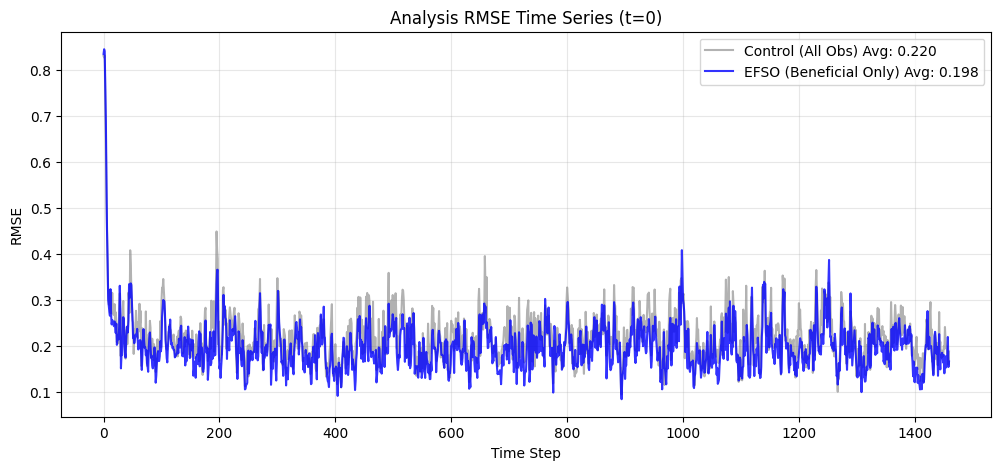

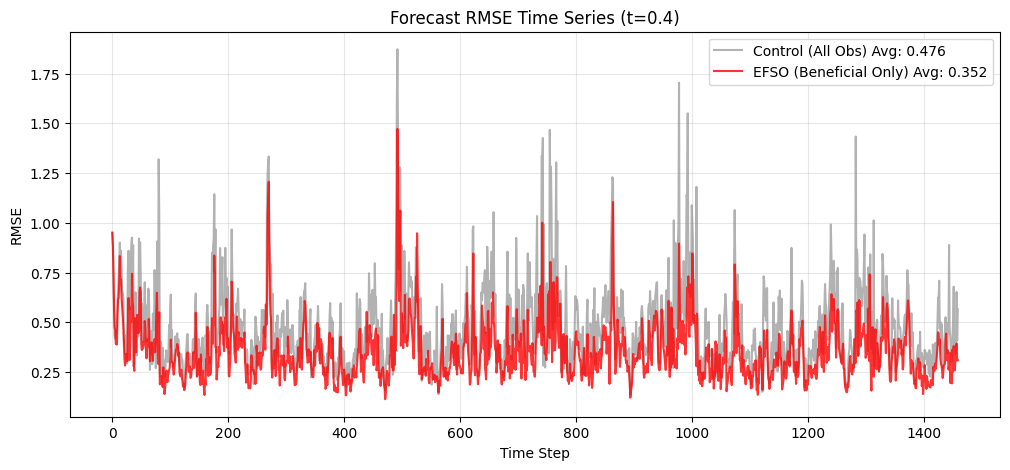

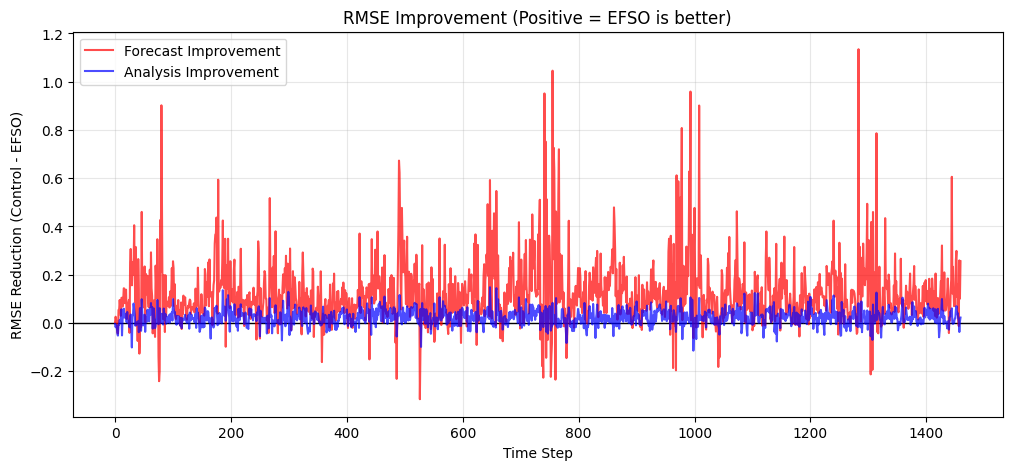

=== Summary (Averaged over 1460 steps) ===
Analysis RMSE: Control=0.2204, EFSO=0.1982
Forecast RMSE: Control=0.4761, EFSO=0.3517
Most Improved Step Index: 647
Improvement at that step: 0.14779


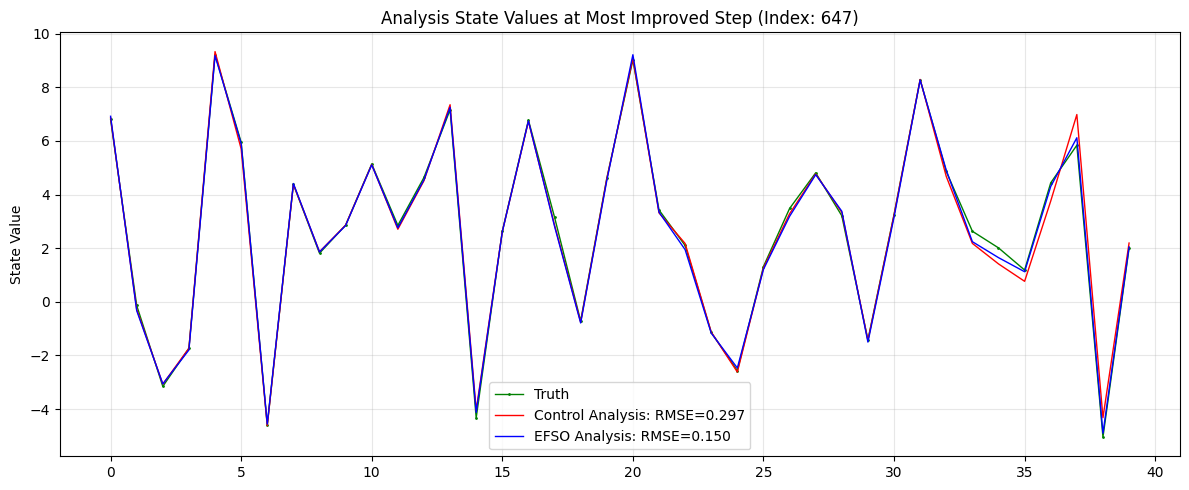

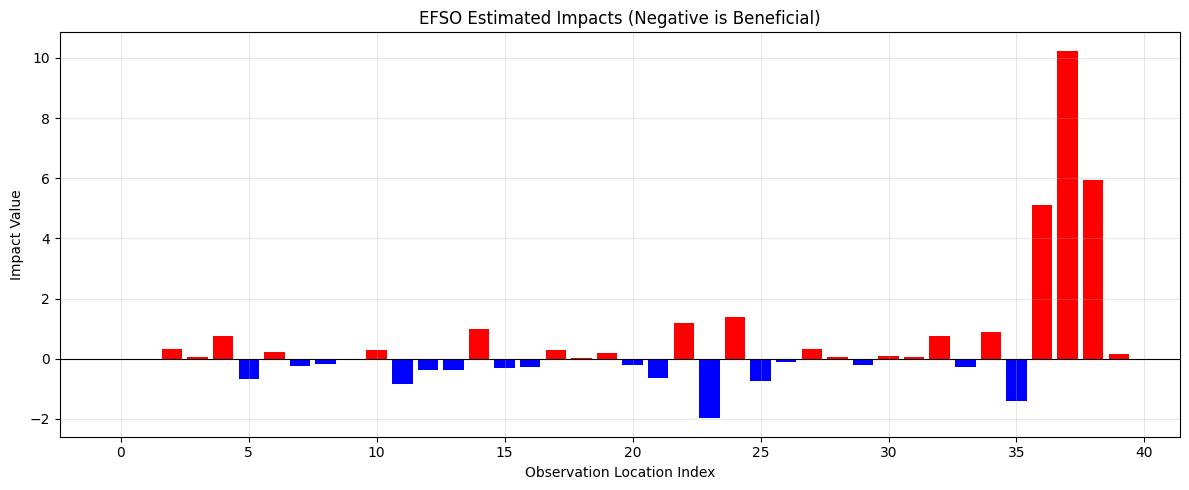

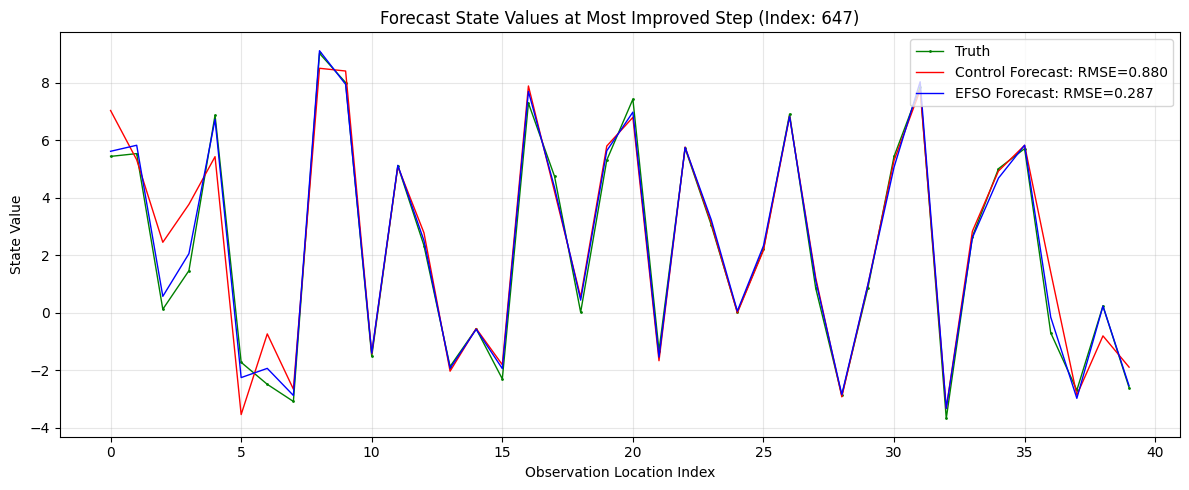

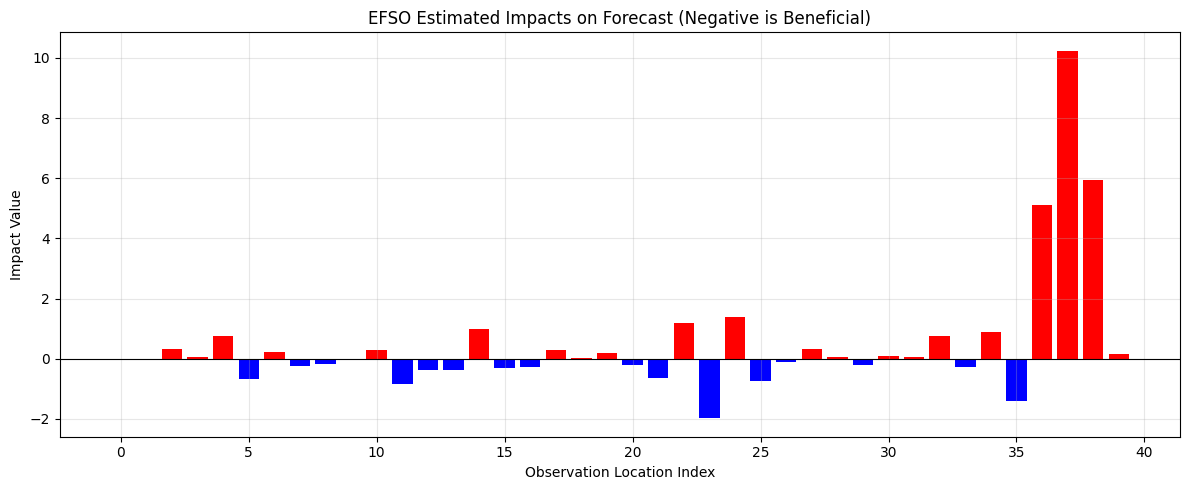

In [32]:
# ==========================================
# 2. LETKF + EFSO Class
# ==========================================
class EnKF_LETKF_EFSO:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.05, loc_radius=5):
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N, N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p) * (obs_error_std**2)
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.inflation_factor = inflation_factor
        self.loc_radius = loc_radius
        
        self.obs_indices = np.where(np.any(self.H, axis=0))[0]
        self.L_mat = self._create_localization_matrix()
        
        self.ensemble = None
        self.ensemble_mean = None

    def _create_localization_matrix(self):
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                if dist < 2 * np.sqrt(10/3) * self.loc_radius:
                    L[i, j] = np.exp(-0.5 * (dist / self.loc_radius) ** 2)
        return L

    def initialize_ensemble(self, x0, initial_spread=1.0):
        np.random.seed(42)
        self.ensemble = x0[:, None] + np.random.normal(0, initial_spread, (self.N, self.ensemble_size))
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        np.random.seed()

    def forecast(self):
        self.ensemble = rk4_step(self.ensemble, self.F, self.dt)
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)

    def analysis(self, observation, active_obs_mask=None):
        X_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Z = (self.ensemble - X_mean) / np.sqrt(self.ensemble_size - 1)
        Z *= self.inflation_factor
        Yb = self.H @ Z
        d = observation.reshape(-1, 1) - (self.H @ X_mean)
        Xa = np.zeros_like(self.ensemble)
        R_inv_diag = 1.0 / np.diag(self.R)
        
        for i in range(self.N):
            weights = self.L_mat[i, self.obs_indices]
            if active_obs_mask is not None:
                weights = weights * active_obs_mask
            
            if np.sum(weights) < 1e-10:
                Xa[i, :] = self.ensemble[i, :]
                continue
            
            R_loc_inv_diag = R_inv_diag * weights
            Y_Rinv = Yb.T * R_loc_inv_diag[None, :] 
            Mat = np.eye(self.ensemble_size) + Y_Rinv @ Yb
            
            try:
                evals, evecs = np.linalg.eigh(Mat)
            except np.linalg.LinAlgError:
                Xa[i, :] = self.ensemble[i, :]
                continue
            
            evals_inv = 1.0 / evals
            P_tilde = evecs @ np.diag(evals_inv) @ evecs.T
            P_tilde_sqrt = evecs @ np.diag(np.sqrt(evals_inv)) @ evecs.T
            
            w_bar = P_tilde @ Y_Rinv @ d
            W_pert = np.sqrt(self.ensemble_size - 1) * P_tilde_sqrt
            W_total = w_bar + W_pert
            Xa[i, :] = X_mean[i, 0] + Z[i, :] @ W_total

        self.ensemble = Xa
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)

    def calculate_efso_impact(self, observation, bg_ensemble, future_reference, verify_steps):
        m = self.ensemble_size
        
        # 1. Analysis Perturbations (X^a)
        xa_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Xa_pert = self.ensemble - xa_mean
        
        # 2. Forecast Perturbations (X^f)
        xf_ens = bg_ensemble.copy()
        for _ in range(verify_steps):
            xf_ens = rk4_step(xf_ens, self.F, self.dt)
        xf_mean = np.mean(xf_ens, axis=1, keepdims=True)
        Xf_pert = xf_ens - xf_mean
        
        # 3. Forecast Error Vector
        xa_fcst = self.ensemble.copy()
        for _ in range(verify_steps):
            xa_fcst = rk4_step(xa_fcst, self.F, self.dt)
        xa_fcst_mean = np.mean(xa_fcst, axis=1, keepdims=True)
        
        ref = future_reference.reshape(-1, 1)
        e_t_0 = xa_fcst_mean - ref
        e_t_m1 = xf_mean - ref
        total_error = e_t_0 + e_t_m1
        
        # 4. Impact Calculation
        w = Xf_pert.T @ total_error
        proj = Xa_pert @ w
        obs_proj = self.H @ proj
        
        bg_mean = np.mean(bg_ensemble, axis=1, keepdims=True)
        innov = observation.reshape(-1, 1) - (self.H @ bg_mean)
        
        R_diag = np.diag(self.R).reshape(-1, 1)
        factor = 1.0 / (m - 1)
        impacts = factor * innov * (1.0 / R_diag) * obs_proj
        
        return impacts.flatten()

# ==========================================
# 3. Main Execution (Diagnostic Mode)
# ==========================================
if __name__ == "__main__":
    # Parameters
    N = 40
    F = 8.0
    dt = 0.05
    ens_size = 20
    cycles = 1460  # 1 year
    verify_steps = 8 # Verification time (2 days later)
    
    # 1. Nature Run
    total_steps = cycles + verify_steps + 100
    truth_gen = StateArray(N, F, dt)
    for _ in range(1000): # Spinup
        truth_gen.step()
    
    truth_trajectory = []
    for _ in range(total_steps):
        truth_gen.step()
        truth_trajectory.append(truth_gen.x.copy())
    truth_trajectory = np.array(truth_trajectory)
    
    # 2. Initialize LETKF
    letkf = EnKF_LETKF_EFSO(N, F, dt, ensemble_size=ens_size)
    letkf.initialize_ensemble(truth_trajectory[0], initial_spread=0.2)
    
    hist_rmse_anl_ctrl = []
    hist_rmse_anl_efso = []
    hist_rmse_fcst_ctrl = []
    hist_rmse_fcst_efso = []
    
    # 各ステップの改善量と詳細データを保存するコンテナ
    hist_analysis_improvement = []
    analysis_details = {}
    hist_forecast_improvement = []
    forecast_details = {}
    
    print(f"Starting Diagnostic Experiment for {cycles} steps...")
    
    for t in range(cycles):
        current_truth = truth_trajectory[t]
        future_truth = truth_trajectory[t + verify_steps]
        
        obs_noise = np.random.normal(0, 1.0, N)
        observation = current_truth + obs_noise
        
        # --- 1. Forecast (Always from previous Control Analysis) ---
        letkf.forecast()
        
        bg_ensemble = letkf.ensemble.copy()
        bg_mean = letkf.ensemble_mean.copy()
        
        # --- 2. Control Analysis (All Obs) ---
        letkf.analysis(observation, active_obs_mask=None)
        xa_ctrl = letkf.ensemble_mean.flatten().copy()
        
        # Save Control State for next cycle
        control_analysis_ensemble = letkf.ensemble.copy()
        
        # --- 3. EFSO Calculation (Diagnostic) ---
        impacts = letkf.calculate_efso_impact(observation, bg_ensemble, future_truth, verify_steps)
        beneficial_mask = impacts < 0.0
        
        # Run EFSO Analysis (Reset -> Analyze)
        letkf.ensemble = bg_ensemble.copy()
        letkf.ensemble_mean = bg_mean.copy()
        letkf.analysis(observation, active_obs_mask=beneficial_mask)
        xa_efso = letkf.ensemble_mean.flatten().copy()
        
        # --- 4. Evaluation ---
        rmse_a_c = np.sqrt(np.mean((xa_ctrl - current_truth)**2))
        rmse_a_p = np.sqrt(np.mean((xa_efso - current_truth)**2))
        
        hist_rmse_anl_ctrl.append(rmse_a_c)
        hist_rmse_anl_efso.append(rmse_a_p)
        
        # Forecast RMSE
        xf_c = xa_ctrl.copy()
        for _ in range(verify_steps): xf_c = rk4_step(xf_c, F, dt)
        rmse_f_c = np.sqrt(np.mean((xf_c - future_truth)**2))
        
        xf_p = xa_efso.copy()
        for _ in range(verify_steps): xf_p = rk4_step(xf_p, F, dt)
        rmse_f_p = np.sqrt(np.mean((xf_p - future_truth)**2))
        
        hist_rmse_fcst_ctrl.append(rmse_f_c)
        hist_rmse_fcst_efso.append(rmse_f_p)
        
        # Improvement & Data Storage
        improvement = rmse_a_c - rmse_a_p
        hist_analysis_improvement.append(improvement)
        
        analysis_details[t] = {
            'xa_ctrl': xa_ctrl,
            'xa_efso': xa_efso,
            'current_truth': current_truth,
            'impacts': impacts
        }
        forecast_improvement = rmse_f_c - rmse_f_p
        hist_forecast_improvement.append(forecast_improvement)
        forecast_details[t] = {
            'xf_ctrl': xf_c,
            'xf_efso': xf_p,
            'future_truth': future_truth,
            'impacts': impacts
        }

        # --- 5. Reset State for Next Cycle (Diagnostic Mode) ---
        letkf.ensemble = control_analysis_ensemble.copy()
        letkf.ensemble_mean = np.mean(letkf.ensemble, axis=1, keepdims=True)
    
    # --- Visualization ---
    time_axis = np.arange(cycles)
    # Plot Analysis RMSE
    control_avg_rmse_anl = np.mean(hist_rmse_anl_ctrl)
    efso_avg_rmse_anl = np.mean(hist_rmse_anl_efso)
    plt.figure(figsize=(12, 5))
    plt.plot(time_axis, hist_rmse_anl_ctrl, label=f'Control (All Obs) Avg: {control_avg_rmse_anl:.3f}', alpha=0.6, color='gray')
    plt.plot(time_axis, hist_rmse_anl_efso, label=f'EFSO (Beneficial Only) Avg: {efso_avg_rmse_anl:.3f}', alpha=0.8, color='blue')
    plt.title("Analysis RMSE Time Series (t=0)")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Plot Forecast RMSE
    control_avg_rmse_fcst = np.mean(hist_rmse_fcst_ctrl)
    efso_avg_rmse_fcst = np.mean(hist_rmse_fcst_efso)
    plt.figure(figsize=(12, 5))
    plt.plot(time_axis, hist_rmse_fcst_ctrl, label=f'Control (All Obs) Avg: {control_avg_rmse_fcst:.3f}', alpha=0.6, color='gray')
    plt.plot(time_axis, hist_rmse_fcst_efso, label=f'EFSO (Beneficial Only) Avg: {efso_avg_rmse_fcst:.3f}', alpha=0.8, color='red')
    plt.title(f"Forecast RMSE Time Series (t={verify_steps*dt:.1f})")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Plot Improvement
    imp_anl = np.array(hist_rmse_anl_ctrl) - np.array(hist_rmse_anl_efso)
    imp_fcst = np.array(hist_rmse_fcst_ctrl) - np.array(hist_rmse_fcst_efso)
    plt.figure(figsize=(12, 5))
    plt.axhline(0, color='black', lw=1)
    plt.plot(time_axis, imp_fcst, label='Forecast Improvement', color='red', alpha=0.7)
    plt.plot(time_axis, imp_anl, label='Analysis Improvement', color='blue', alpha=0.7)
    plt.title("RMSE Improvement (Positive = EFSO is better)")
    plt.xlabel("Time Step")
    plt.ylabel("RMSE Reduction (Control - EFSO)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Print Summary Statistics
    print(f"=== Summary (Averaged over {cycles} steps) ===")
    print(f"Analysis RMSE: Control={control_avg_rmse_anl:.4f}, EFSO={efso_avg_rmse_anl:.4f}")
    print(f"Forecast RMSE: Control={control_avg_rmse_fcst:.4f}, EFSO={efso_avg_rmse_fcst:.4f}")


    ## 単一ステップの詳細解析と可視化 ##
    # --- Find Best Improved Step ---
    best_step_idx = np.argmax(hist_analysis_improvement)
    best_improvement = hist_analysis_improvement[best_step_idx]
    best_step_data = analysis_details[best_step_idx]
    
    print(f"Most Improved Step Index: {best_step_idx}")
    print(f"Improvement at that step: {best_improvement:.5f}")

    # --- Visualization for Best Improved Step ---
    obs_indices = np.arange(N)
    
    
    # State Values
    rmse_ctrl = np.sqrt(np.mean((best_step_data['xa_ctrl'] - best_step_data['current_truth'])**2))
    rmse_efso = np.sqrt(np.mean((best_step_data['xa_efso'] - best_step_data['current_truth'])**2))
    plt.figure(figsize=(12, 5))
    plt.plot(obs_indices, best_step_data['current_truth'], label='Truth', color='green', linestyle='-', marker='o', markersize=1, linewidth=1)
    plt.plot(obs_indices, best_step_data['xa_ctrl'], label=f'Control Analysis: RMSE={rmse_ctrl:.3f}', color='red', linestyle='-', linewidth=1)
    plt.plot(obs_indices, best_step_data['xa_efso'], label=f'EFSO Analysis: RMSE={rmse_efso:.3f}', color='blue', linestyle='-', linewidth=1)
    plt.title(f"Analysis State Values at Most Improved Step (Index: {best_step_idx})")
    plt.ylabel("State Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Impacts
    plt.figure(figsize=(12, 5))
    impacts = best_step_data['impacts']
    colors = ['red' if val > 0 else 'blue' for val in impacts] # red=detrimental, blue=beneficial
    plt.bar(obs_indices, impacts, color=colors)
    plt.axhline(0, color='black', lw=0.8)
    plt.title("EFSO Estimated Impacts (Negative is Beneficial)")
    plt.xlabel("Observation Location Index")
    plt.ylabel("Impact Value")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    # --- Forecast Details for Best Improved Step ---
    best_forecast_data = forecast_details[best_step_idx]
    rmse_fcst_ctrl = np.sqrt(np.mean((best_forecast_data['xf_ctrl'] - best_forecast_data['future_truth'])**2))
    rmse_fcst_efso = np.sqrt(np.mean((best_forecast_data['xf_efso'] - best_forecast_data['future_truth'])**2))
    plt.figure(figsize=(12, 5))
    plt.plot(obs_indices, best_forecast_data['future_truth'], label='Truth', color='green', linestyle='-', marker='o', markersize=1, linewidth=1)
    plt.plot(obs_indices, best_forecast_data['xf_ctrl'], label=f'Control Forecast: RMSE={rmse_fcst_ctrl:.3f}', color='red', linestyle='-', linewidth=1)
    plt.plot(obs_indices, best_forecast_data['xf_efso'], label=f'EFSO Forecast: RMSE={rmse_fcst_efso:.3f}', color='blue', linestyle='-', linewidth=1)
    plt.title(f"Forecast State Values at Most Improved Step (Index: {best_step_idx})")
    plt.ylabel("State Value")
    plt.xlabel("Observation Location Index")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    #impacts
    plt.figure(figsize=(12, 5))
    impacts_fcst = best_forecast_data['impacts']
    colors_fcst = ['red' if val > 0 else 'blue' for val in impacts_fcst] # red=detrimental, blue=beneficial
    plt.bar(obs_indices, impacts_fcst, color=colors_fcst)
    plt.axhline(0, color='black', lw=0.8)
    plt.title("EFSO Estimated Impacts on Forecast (Negative is Beneficial)")
    plt.xlabel("Observation Location Index")
    plt.ylabel("Impact Value")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()